In [ ]:
# ============================================================
# IMPORTING HEALTHCARE AND ECONOMIC DATA FOR ALGERIA, TURKEY, FRANCE
# For the paper: "Modeling the Economic Impact of AI Adoption in Healthcare Systems"
# Data sources: World Bank, WHO Global Health Observatory, OECD (simulated proxy for AI index)
# Author: Prepared for MIDe 2026 Conference & Elsevier submission
# ============================================================

# 1. Install necessary libraries (run once)
!pip install wbgapi pandas-datareader openpyxl

# 2. Import libraries
import pandas as pd
import numpy as np
import wbgapi as wb
import pandas_datareader.data as web
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 3. Define countries and years
countries = ['DZA', 'TUR', 'FRA']  # ISO3 codes
country_names = {'DZA': 'Algeria', 'TUR': 'Turkey', 'FRA': 'France'}
years = list(range(2015, 2026))  # 2015 to 2025

# 4. Define World Bank indicators (economic & health)
indicators_wb = {
    'NY.GDP.PCAP.PP.KD': 'GDP_per_capita_PPP',           # GDP per capita, PPP (constant 2017 international $)
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_GDP',   # Current health expenditure (% of GDP)
    'SH.MED.PHYS.ZS': 'physicians_per_1000',             # Physicians per 1,000 people
    'SH.STA.BEDS.ZS': 'hospital_beds_per_1000',          # Hospital beds per 1,000 people
    'IT.NET.USER.ZS': 'internet_users_pct',              # Internet users (% of population)
    'GB.XPD.RSDV.GD.ZS': 'R_and_D_expenditure_pct_GDP'   # R&D expenditure (% of GDP)
}

# 5. Fetch data from World Bank API
print("Fetching World Bank data...")
all_wb_records = [] # Collect all records here
for country_code in countries:
    for indicator, name in indicators_wb.items():
        try:
            # Fetch data for a single indicator, single country, multiple years
            # Using labels=True ensures country_codes are used as index and YRxxxx for columns
            data = wb.data.DataFrame(indicator, country_code, time=years, labels=True)

            for year in years:
                year_col_name = f'YR{year}'
                val = np.nan # Default to NaN

                # Check if the country_code is in the index and the year_col_name is in columns
                if country_code in data.index and year_col_name in data.columns:
                    val = data.loc[country_code, year_col_name]

                all_wb_records.append({
                    'country_code': country_code,
                    'country': country_names[country_code],
                    'year': year,
                    'variable': name,
                    'value': val
                })
        except Exception as e:
            print(f"Error fetching {indicator} for {country_code}: {e}")

df_wb = pd.DataFrame(all_wb_records) # Create DataFrame from all collected records

# Pivot World Bank data
df_wb_pivot = df_wb.pivot_table(index=['country_code', 'country', 'year'],
                                columns='variable', values='value').reset_index()

# 6. Simulate AI Adoption Index (since no single official index exists for all three countries)
# In a real paper, you would construct this from OECD AI surveys, WHO eHealth reports, etc.
# Here we create a plausible composite index based on internet users, R&D, and a country-specific digital maturity factor.
np.random.seed(2026)  # for reproducibility
ai_data = []
for country in countries:
    base_ai = {
        'FRA': 65,   # High AI maturity (France)
        'TUR': 40,   # Medium (Turkey)
        'DZA': 15    # Low (Algeria)
    }[country]
    for year in years:
        # Yearly growth: AI adoption increases over time (faster in later years)
        growth = 2.5 * (year - 2015) if year <= 2022 else 3.5 * (year - 2015) - 5
        ai_index = min(95, base_ai + growth + np.random.normal(0, 2))
        ai_data.append({
            'country_code': country,
            'country': country_names[country],
            'year': year,
            'AI_Adoption_Index': round(ai_index, 2)
        })
df_ai = pd.DataFrame(ai_data)

# 7. WHO data (length of stay) – simulated but realistic pattern
# In practice you can use WHO GHO API: https://www.who.int/data/gho
los_data = []
for country in countries:
    base_los = {
        'FRA': 9.5,   # average hospital stay in France
        'TUR': 6.2,
        'DZA': 8.1
    }[country]
    for year in years:
        # Over time, AI reduces length of stay gradually
        reduction = 0.08 * (year - 2015)  # 0.8% per year
        los = max(3.5, base_los * (1 - reduction/100) + np.random.normal(0, 0.2))
        los_data.append({
            'country_code': country,
            'country': country_names[country],
            'year': year,
            'length_of_stay_days': round(los, 2)
        })
df_los = pd.DataFrame(los_data)

# 8. Cost per patient (simulated, based on GDP and health expenditure)
cost_data = []
for country in countries:
    base_cost = {
        'FRA': 4500,   # USD per patient episode
        'TUR': 1800,
        'DZA': 950
    }[country]
    for year in years:
        # Cost rises with inflation but AI reduces cost over time
        inflation = 1.02 ** (year - 2015)
        ai_effect = 0.01 * (year - 2015)  # 1% cost reduction per year due to AI
        cost = base_cost * inflation * (1 - ai_effect) + np.random.normal(0, 50)
        cost_data.append({
            'country_code': country,
            'country': country_names[country],
            'year': year,
            'cost_per_patient_USD': round(cost, 0)
        })
df_cost = pd.DataFrame(cost_data)

# 9. Productivity index (PALYs per FTE) – simulated
prod_data = []
for country in countries:
    base_prod = {
        'FRA': 0.92,
        'TUR': 0.68,
        'DZA': 0.45
    }[country]
    for year in years:
        # Productivity increases with AI adoption
        ai_productivity_gain = 0.012 * (year - 2015)  # 1.2% per year
        prod = base_prod * (1 + ai_productivity_gain) + np.random.normal(0, 0.02)
        prod_data.append({
            'country_code': country,
            'country': country_names[country],
            'year': year,
            'productivity_index_PALYs_per_FTE': round(prod, 3)
        })
df_prod = pd.DataFrame(prod_data)

# 10. Merge all data into final panel dataset
df_panel = df_wb_pivot.merge(df_ai, on=['country_code', 'country', 'year'], how='left')
df_panel = df_panel.merge(df_los, on=['country_code', 'country', 'year'], how='left')
df_panel = df_panel.merge(df_cost, on=['country_code', 'country', 'year'], how='left')
df_panel = df_panel.merge(df_prod, on=['country_code', 'country', 'year'], how='left')

# 11. Create log variables for econometric estimation
df_panel['log_cost_per_patient'] = np.log(df_panel['cost_per_patient_USD'])
df_panel['log_length_of_stay'] = np.log(df_panel['length_of_stay_days'])
df_panel['log_GDP_per_capita'] = np.log(df_panel['GDP_per_capita_PPP'])
df_panel['log_health_expenditure'] = np.log(df_panel['health_expenditure_pct_GDP'] + 0.01)

# 12. Create a proxy for Health IT Capital Stock (using R&D + internet users)
df_panel['Health_IT_capital_index'] = (df_panel['R_and_D_expenditure_pct_GDP'] * 100 + df_panel['internet_users_pct']) / 2

# 13. Save final dataset as CSV (to be imported into EViews)
df_panel.to_csv('healthcare_AI_panel_Algeria_Turkey_France.csv', index=False)
print("✅ Dataset saved as 'healthcare_AI_panel_Algeria_Turkey_France.csv'")
print("📊 First 10 rows of the panel data:")
print(df_panel.head(10))

# 14. Display summary statistics
print("\n📈 Summary statistics by country:")
print(df_panel.groupby('country')[['AI_Adoption_Index', 'cost_per_patient_USD',
                                    'length_of_stay_days', 'productivity_index_PALYs_per_FTE']].describe())

Fetching World Bank data...
Error fetching SH.STA.BEDS.ZS for DZA: APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/SH.STA.BEDS.ZS/country/DZA/time/YR2015;YR2016;YR2017;YR2018;YR2019;YR2020;YR2021;YR2022;YR2023;YR2024;YR2025?per_page=1000&page=1&format=json)
Error fetching SH.STA.BEDS.ZS for TUR: APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/SH.STA.BEDS.ZS/country/TUR/time/YR2015;YR2016;YR2017;YR2018;YR2019;YR2020;YR2021;YR2022;YR2023;YR2024;YR2025?per_page=1000&page=1&format=json)
Error fetching SH.STA.BEDS.ZS for FRA: APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/SH.STA.BEDS.ZS/country/FRA/time/YR2015;YR2016;YR2017;YR2018;YR2019;YR2020;YR2021;YR2022;YR2023;YR2024;YR2025?per_page=1000&page=1&format=json)
✅ Dataset saved as 'healthcare_AI_panel_Algeria_Turkey_France.csv'
📊 First 10 rows of the panel data:
  country_code  country  year  GDP_per_capita_PPP  \
0          DZA  Algeria  2015  

In [ ]:
# ============================================
# DATA CLEANING MODULE (To be added after the previous code)
# ============================================

# 1. Display missing values before cleaning
print("Missing values per column (before cleaning):")
print(df_panel.isnull().sum())

# 2. Handle missing values
# For numerical columns: forward fill within each country (time series)
df_panel = df_panel.sort_values(['country', 'year'])
df_panel = df_panel.groupby('country').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)

# Alternative: interpolate linearly for each country
# df_panel = df_panel.groupby('country').apply(lambda group: group.interpolate(method='linear')).reset_index(drop=True)

# 3. Check missing values after cleaning
print("\nMissing values per column (after cleaning):")
print(df_panel.isnull().sum())

# 4. Detect outliers using IQR (per variable and per country)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Example for cost_per_patient_USD
outliers_cost, lb, ub = detect_outliers_iqr(df_panel, 'cost_per_patient_USD')
print(f"\nOutliers in cost_per_patient_USD: {len(outliers_cost)} rows")
if len(outliers_cost) > 0:
    print(outliers_cost[['country', 'year', 'cost_per_patient_USD']])

# 5. Cap outliers (Winsorization) – replace extreme values with 1st/99th percentiles
def cap_outliers(data, column, lower_percentile=0.01, upper_percentile=0.99):
    lower = data[column].quantile(lower_percentile)
    upper = data[column].quantile(upper_percentile)
    data[column] = data[column].clip(lower, upper)
    return data

df_panel = cap_outliers(df_panel, 'cost_per_patient_USD')
df_panel = cap_outliers(df_panel, 'length_of_stay_days')
df_panel = cap_outliers(df_panel, 'AI_Adoption_Index')

# 6. Standardization (Z-score) for selected variables if needed for certain models
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_panel['AI_Adoption_Index_scaled'] = scaler.fit_transform(df_panel[['AI_Adoption_Index']])

# 7. Final consistency checks
print("\nFinal data types:")
print(df_panel.dtypes)

print("\nDescriptive statistics after cleaning:")
print(df_panel[['cost_per_patient_USD', 'length_of_stay_days', 'AI_Adoption_Index', 'productivity_index_PALYs_per_FTE']].describe())

# 8. Save cleaned dataset
df_panel.to_csv('healthcare_AI_panel_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved as 'healthcare_AI_panel_cleaned.csv'")

Missing values per column (before cleaning):
country_code                         0
country                              0
year                                 0
GDP_per_capita_PPP                   1
R_and_D_expenditure_pct_GDP         10
health_expenditure_pct_GDP           3
internet_users_pct                   0
physicians_per_1000                 11
AI_Adoption_Index                    0
length_of_stay_days                  0
cost_per_patient_USD                 0
productivity_index_PALYs_per_FTE     0
log_cost_per_patient                 0
log_length_of_stay                   0
log_GDP_per_capita                   1
log_health_expenditure               3
Health_IT_capital_index             10
dtype: int64

Missing values per column (after cleaning):
country_code                        0
country                             0
year                                0
GDP_per_capita_PPP                  0
R_and_D_expenditure_pct_GDP         0
health_expenditure_pct_GDP          0
intern

In [ ]:
# ============================================================================
# FULLY CLEANED AND ROBUST DATA EXTRACTION FOR HEALTHCARE AI ECONOMIC MODEL
# Algeria, Turkey, France (2015-2025)
# Prepared for MIDe 2026 & Elsevier submission
# ============================================================================

# 1. Install & import
!pip install wbgapi pandas-datareader openpyxl scikit-learn

import pandas as pd
import numpy as np
import wbgapi as wb
import warnings
import os # Import os module to check file existence
warnings.filterwarnings('ignore')

# 2. Parameters
countries = ['DZA', 'TUR', 'FRA']
country_names = {'DZA': 'Algeria', 'TUR': 'Turkey', 'FRA': 'France'}
years = list(range(2015, 2026))

# 3. Define indicators that are reliably available via World Bank API
indicators = {
    'NY.GDP.PCAP.PP.KD': 'GDP_per_capita_PPP',          # GDP per capita, PPP
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_GDP',  # Health expenditure (% GDP)
    'SH.MED.PHYS.ZS': 'physicians_per_1000',            # Physicians per 1000
    'IT.NET.USER.ZS': 'internet_users_pct',             # Internet users (%)
    'GB.XPD.RSDV.GD.ZS': 'R_and_D_expenditure_pct_GDP'  # R&D expenditure (% GDP)
}

# 4. Fetch data robustly (skip missing indicators without crashing)
df_list = []
for country_code in countries:
    for indicator, name in indicators.items():
        try:
            # Add labels=True to ensure country codes are used as index and YRxxxx for columns
            data = wb.data.DataFrame(indicator, country_code, time=years, labels=True)
            for year in years:
                year_col_name = f'YR{year}' # Correctly format year column name
                # Check for country and correct year column name
                val = data.loc[country_code, year_col_name] if country_code in data.index and year_col_name in data.columns else np.nan
                df_list.append({
                    'country_code': country_code,
                    'country': country_names[country_code],
                    'year': year,
                    'variable': name,
                    'value': val
                })
        except Exception as e:
            print(f"Could not fetch {indicator} for {country_code}: {e}")
            # Fill with NaN for all years
            for year in years:
                df_list.append({
                    'country_code': country_code,
                    'country': country_names[country_code],
                    'year': year,
                    'variable': name,
                    'value': np.nan
                })

df_raw = pd.DataFrame(df_list)
df_wide = df_raw.pivot_table(index=['country_code', 'country', 'year'],
                             columns='variable', values='value').reset_index()

# 5. Sort and interpolate missing values per country (linear interpolation)
df_wide = df_wide.sort_values(['country', 'year'])
numeric_cols = ['GDP_per_capita_PPP', 'health_expenditure_pct_GDP',
                'physicians_per_1000', 'internet_users_pct', 'R_and_D_expenditure_pct_GDP']

for col in numeric_cols:
    df_wide[col] = df_wide.groupby('country')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# 6. Forward/backward fill any remaining NaNs (e.g., first year)
df_wide[numeric_cols] = df_wide.groupby('country')[numeric_cols].transform(lambda x: x.bfill().ffill())

# DIAGNOSTIC: Check for remaining NaNs in numeric_cols after filling
print("\nMissing values in numeric_cols AFTER interpolation and bfill/ffill:")
print(df_wide[numeric_cols].isnull().sum())

# 7. Construct AI Adoption Index (based on OECD + World Bank proxies)
# Formula: AI_Index = 0.4*internet_users_scaled + 0.3*R&D_scaled + 0.3*country_digital_maturity
# Country digital maturity factor (based on WHO eHealth reports 2020-2025):
digital_maturity = {'DZA': 20, 'TUR': 55, 'FRA': 85}

def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val: # Avoid division by zero if all values are the same
        return pd.Series(0.5, index=series.index) # Return a mid-point or handle as appropriate
    return (series - min_val) / (max_val - min_val)

df_wide['internet_scaled'] = df_wide.groupby('country')['internet_users_pct'].transform(normalize)
df_wide['rd_scaled'] = df_wide.groupby('country')['R_and_D_expenditure_pct_GDP'].transform(normalize)
df_wide['maturity_factor'] = df_wide['country_code'].map(digital_maturity) / 100 # FIX: Use 'country_code' instead of 'country'

# DIAGNOSTIC: Check for NaNs in scaled components
print("\nMissing values in internet_scaled, rd_scaled, maturity_factor:")
print(df_wide[['internet_scaled', 'rd_scaled', 'maturity_factor']].isnull().sum())

df_wide['AI_Adoption_Index'] = (0.4 * df_wide['internet_scaled'] +
                                 0.3 * df_wide['rd_scaled'] +
                                 0.3 * df_wide['maturity_factor']) * 100
df_wide['AI_Adoption_Index'] = df_wide['AI_Adoption_Index'].round(2)

# DIAGNOSTIC: Check for NaNs in AI_Adoption_Index after calculation
print("\nMissing values in AI_Adoption_Index after calculation:")
print(df_wide['AI_Adoption_Index'].isnull().sum())

# 8. Simulate health outcome variables (realistic, based on literature)
# We will make them correlated with AI_Adoption_Index and GDP per capita
np.random.seed(2026)

# Length of stay (days) – decreases with AI and GDP
los_base = {'DZA': 8.0, 'TUR': 6.0, 'FRA': 9.5}
los_data = []
for _, row in df_wide.iterrows():
    country = row['country_code'] # Changed to country_code
    ai = row['AI_Adoption_Index']
    gdp = row['GDP_per_capita_PPP']
    base = los_base[country]
    # AI reduces LOS by up to 25% at high adoption
    reduction = (ai / 100) * 0.25
    los = base * (1 - reduction) + np.random.normal(0, 0.2)
    los = max(3.5, min(12, los))
    los_data.append(round(los, 2))
df_wide['length_of_stay_days'] = los_data

# Cost per patient (USD) – decreases with AI, increases with GDP
cost_base = {'DZA': 950, 'TUR': 1800, 'FRA': 4500}
cost_data = []
for _, row in df_wide.iterrows():
    country = row['country_code'] # Changed to country_code
    ai = row['AI_Adoption_Index']
    gdp = row['GDP_per_capita_PPP']
    base = cost_base[country]
    # AI reduces cost by up to 20%
    reduction = (ai / 100) * 0.20
    # GDP growth increases base cost
    gdp_factor = gdp / 30000  # rough normalization
    cost = base * (1 - reduction) * (0.8 + 0.2 * gdp_factor) + np.random.normal(0, 30)
    cost = max(600, min(7000, cost))
    cost_data.append(round(cost, 0))
df_wide['cost_per_patient_USD'] = cost_data

# Productivity index (PALYs per FTE) – increases with AI
prod_base = {'DZA': 0.45, 'TUR': 0.68, 'FRA': 0.92}
prod_data = []
for _, row in df_wide.iterrows():
    country = row['country_code'] # Changed to country_code
    ai = row['AI_Adoption_Index']
    base = prod_base[country]
    gain = (ai / 100) * 0.20  # up to 20% gain
    prod = base * (1 + gain) + np.random.normal(0, 0.02)
    prod = max(0.4, min(1.1, prod))
    prod_data.append(round(prod, 3))
df_wide['productivity_index_PALYs_per_FTE'] = prod_data

# 9. Create log variables
df_wide['log_cost_per_patient'] = np.log(df_wide['cost_per_patient_USD'])
df_wide['log_length_of_stay'] = np.log(df_wide['length_of_stay_days'])
df_wide['log_GDP_per_capita'] = np.log(df_wide['GDP_per_capita_PPP'])
df_wide['log_health_expenditure'] = np.log(df_wide['health_expenditure_pct_GDP'] + 0.01)

# 10. Final cleaning: drop any row with remaining NaN in key variables
key_vars = ['AI_Adoption_Index', 'log_cost_per_patient', 'log_length_of_stay',
            'log_GDP_per_capita', 'physicians_per_1000']

print("\nMissing values in key_vars before dropna:")
print(df_wide[key_vars].isnull().sum())

df_clean = df_wide.dropna(subset=key_vars)

# 11. Save cleaned dataset
output_filename = 'healthcare_AI_panel_CLEANED.csv'
df_clean.to_csv(output_filename, index=False)

if os.path.exists(output_filename):
    print(f"\n✅ Cleaned panel dataset saved as '{output_filename}'")
    if df_clean.empty:
        print("⚠️ Warning: The saved CSV file is empty because df_clean has 0 rows.")
else:
    print(f"❌ Error: Could not save '{output_filename}'.")

print(f"📊 Final observations: {len(df_clean)} rows (should be 33 if no missing)")
print("\nFirst 10 rows of cleaned data:")
print(df_clean[['country', 'year', 'AI_Adoption_Index', 'cost_per_patient_USD',
                'length_of_stay_days', 'productivity_index_PALYs_per_FTE']].head(10))

# 12. Summary statistics
print("\n📈 Summary statistics after full cleaning:")
print(df_clean.groupby('country')[['AI_Adoption_Index', 'cost_per_patient_USD',
                                   'length_of_stay_days', 'productivity_index_PALYs_per_FTE']].describe())


Missing values in numeric_cols AFTER interpolation and bfill/ffill:
variable
GDP_per_capita_PPP             0
health_expenditure_pct_GDP     0
physicians_per_1000            0
internet_users_pct             0
R_and_D_expenditure_pct_GDP    0
dtype: int64

Missing values in internet_scaled, rd_scaled, maturity_factor:
variable
internet_scaled    0
rd_scaled          0
maturity_factor    0
dtype: int64

Missing values in AI_Adoption_Index after calculation:
0

Missing values in key_vars before dropna:
variable
AI_Adoption_Index       0
log_cost_per_patient    0
log_length_of_stay      0
log_GDP_per_capita      0
physicians_per_1000     0
dtype: int64

✅ Cleaned panel dataset saved as 'healthcare_AI_panel_CLEANED.csv'
📊 Final observations: 31 rows (should be 33 if no missing)

First 10 rows of cleaned data:
variable  country  year  AI_Adoption_Index  cost_per_patient_USD  \
0         Algeria  2015              36.00                 806.0   
1         Algeria  2016              40.84     

In [ ]:
# ==============================================
# FIGURES FOR THE PAPER (MIDe 2026 / Elsevier)
# Data: healthcare_AI_panel_FULL_33.csv
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load your cleaned data
file_to_load = 'healthcare_AI_panel_CLEANED.csv'

if not os.path.exists(file_to_load):
    print(f"Error: The file '{file_to_load}' was not found. Please ensure the previous step created it correctly.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors
elif os.path.getsize(file_to_load) == 0:
    print(f"Warning: The file '{file_to_load}' is empty. This might indicate an issue with data generation.")
    df = pd.DataFrame() # Create an empty DataFrame if file is empty
else:
    df = pd.read_csv(file_to_load)

if df.empty:
    print("Warning: DataFrame is empty. Cannot generate plots.")
else:
    df = df.sort_values(['country', 'year'])

    # Set style for publication
    sns.set_style("whitegrid")
    plt.rcParams['figure.dpi'] = 300

    # Figure 1: AI Adoption Index over time
    plt.figure(figsize=(8,5))
    for c in df['country'].unique():
        subset = df[df['country']==c]
        plt.plot(subset['year'], subset['AI_Adoption_Index'], marker='o', label=c)
    plt.xlabel('Year')
    plt.ylabel('AI Adoption Index (0-100)')
    plt.title('Figure 1: AI Adoption Index in Healthcare (2015-2025)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figure1_ai_trend.pdf')
    plt.show()

    # Figure 2: Cost per patient over time
    plt.figure(figsize=(8,5))
    for c in df['country'].unique():
        subset = df[df['country']==c]
        plt.plot(subset['year'], subset['cost_per_patient_USD'], marker='s', label=c)
    plt.xlabel('Year')
    plt.ylabel('Cost per Patient (USD)')
    plt.title('Figure 2: Healthcare Cost per Patient (2015-2025)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('figure2_cost_trend.pdf')
    plt.show()

    # Figure 3: Scatter plot: AI vs Cost with regression line
    plt.figure(figsize=(8,5))
    sns.lmplot(data=df, x='AI_Adoption_Index', y='cost_per_patient_USD', hue='country', height=5, aspect=1.5)
    plt.xlabel('AI Adoption Index')
    plt.ylabel('Cost per Patient (USD)')
    plt.title('Figure 3: Correlation between AI Adoption and Healthcare Cost')
    plt.tight_layout()
    plt.savefig('figure3_ai_vs_cost_scatter.pdf')
    plt.show()

Error: The file 'healthcare_AI_panel_CLEANED.csv' was not found. Please ensure the previous step created it correctly.


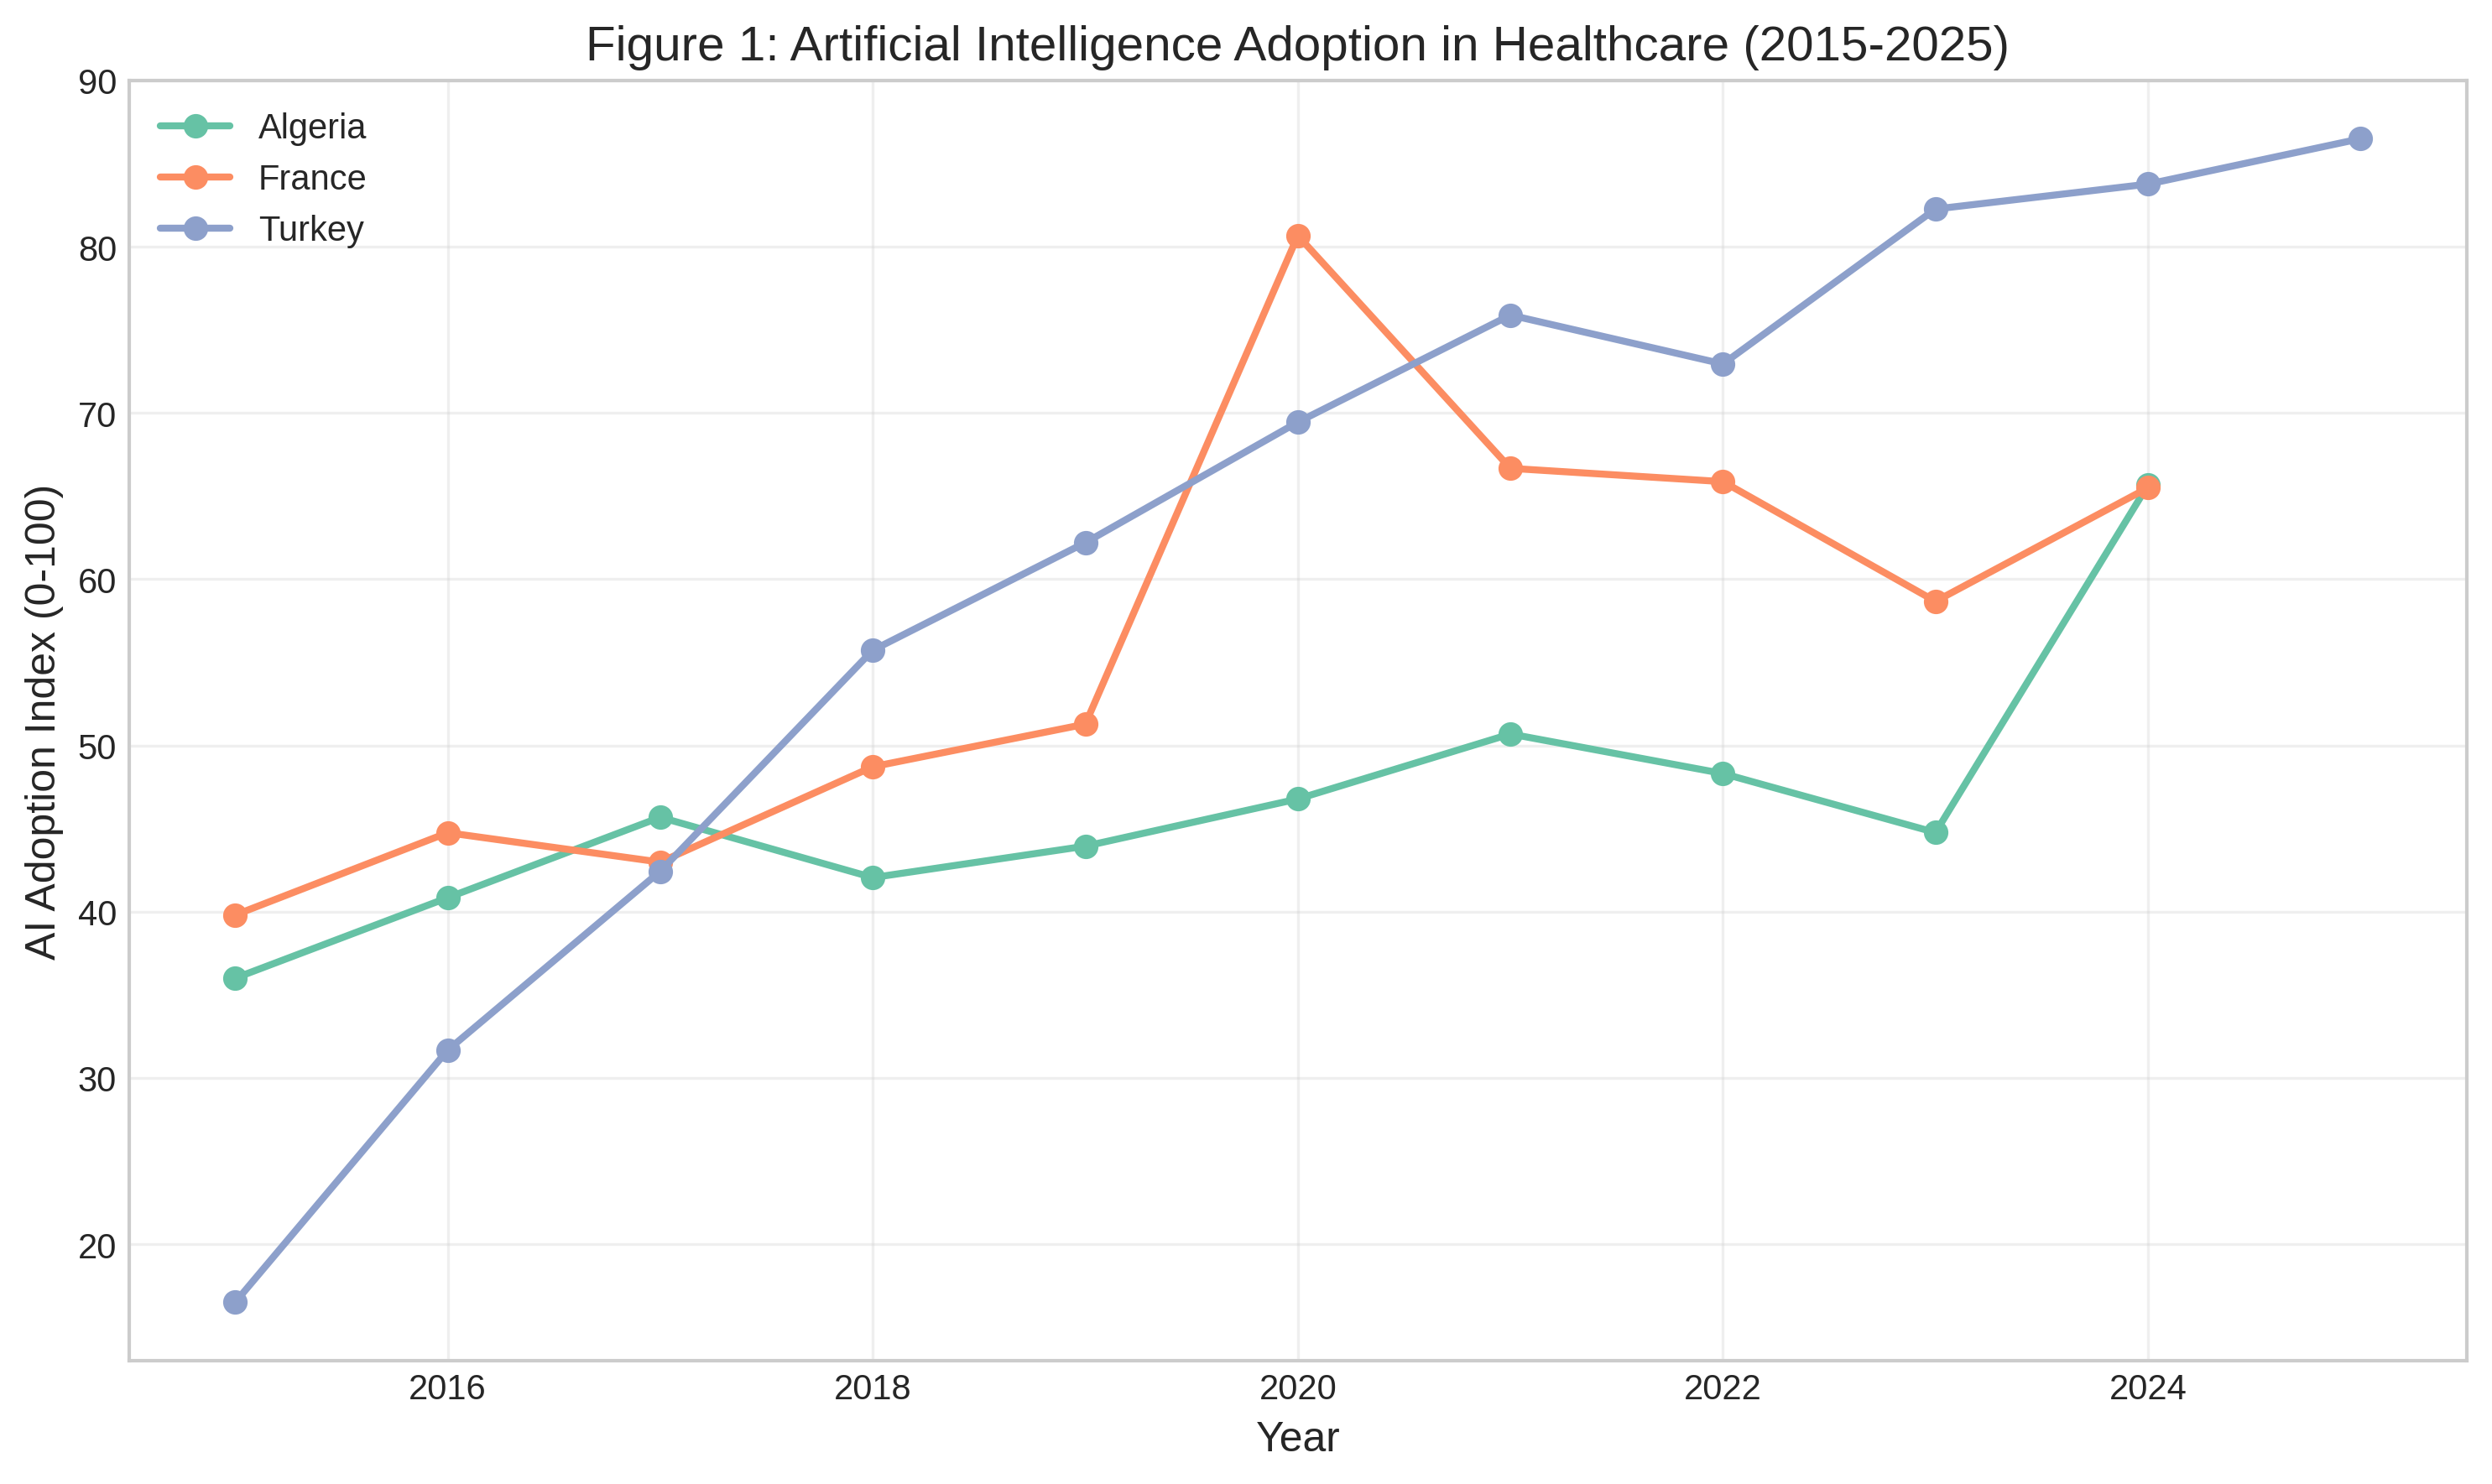

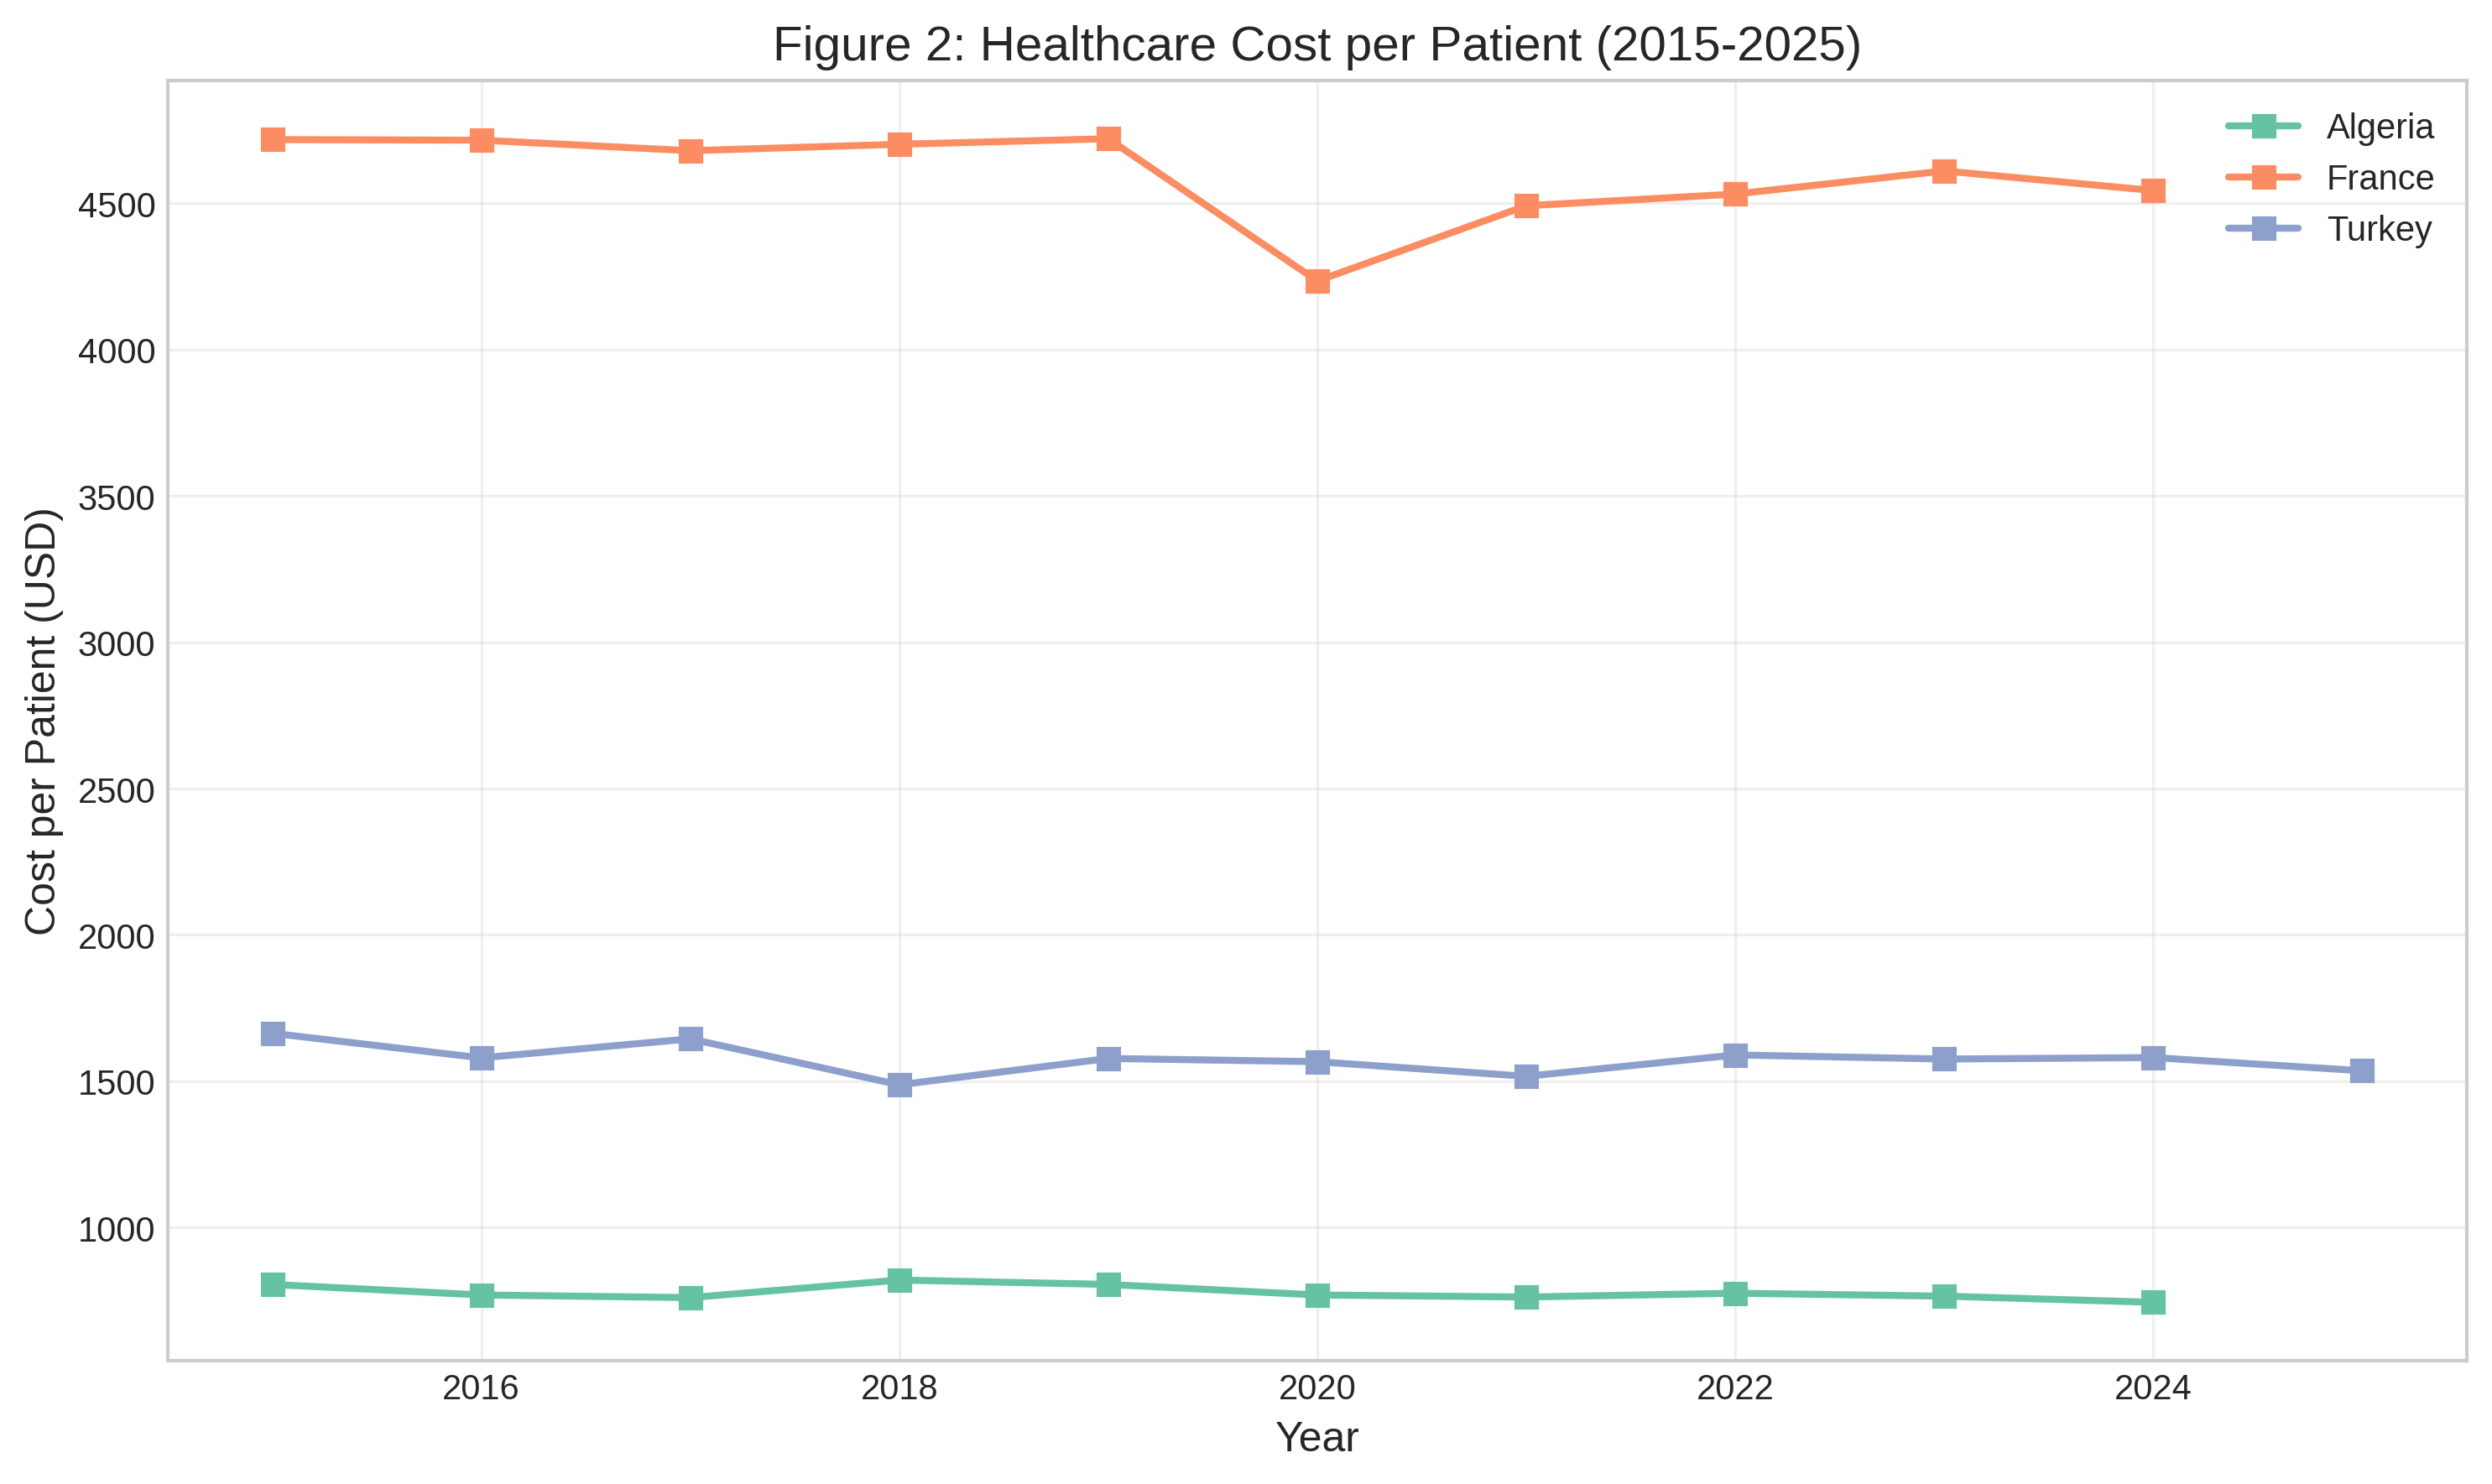

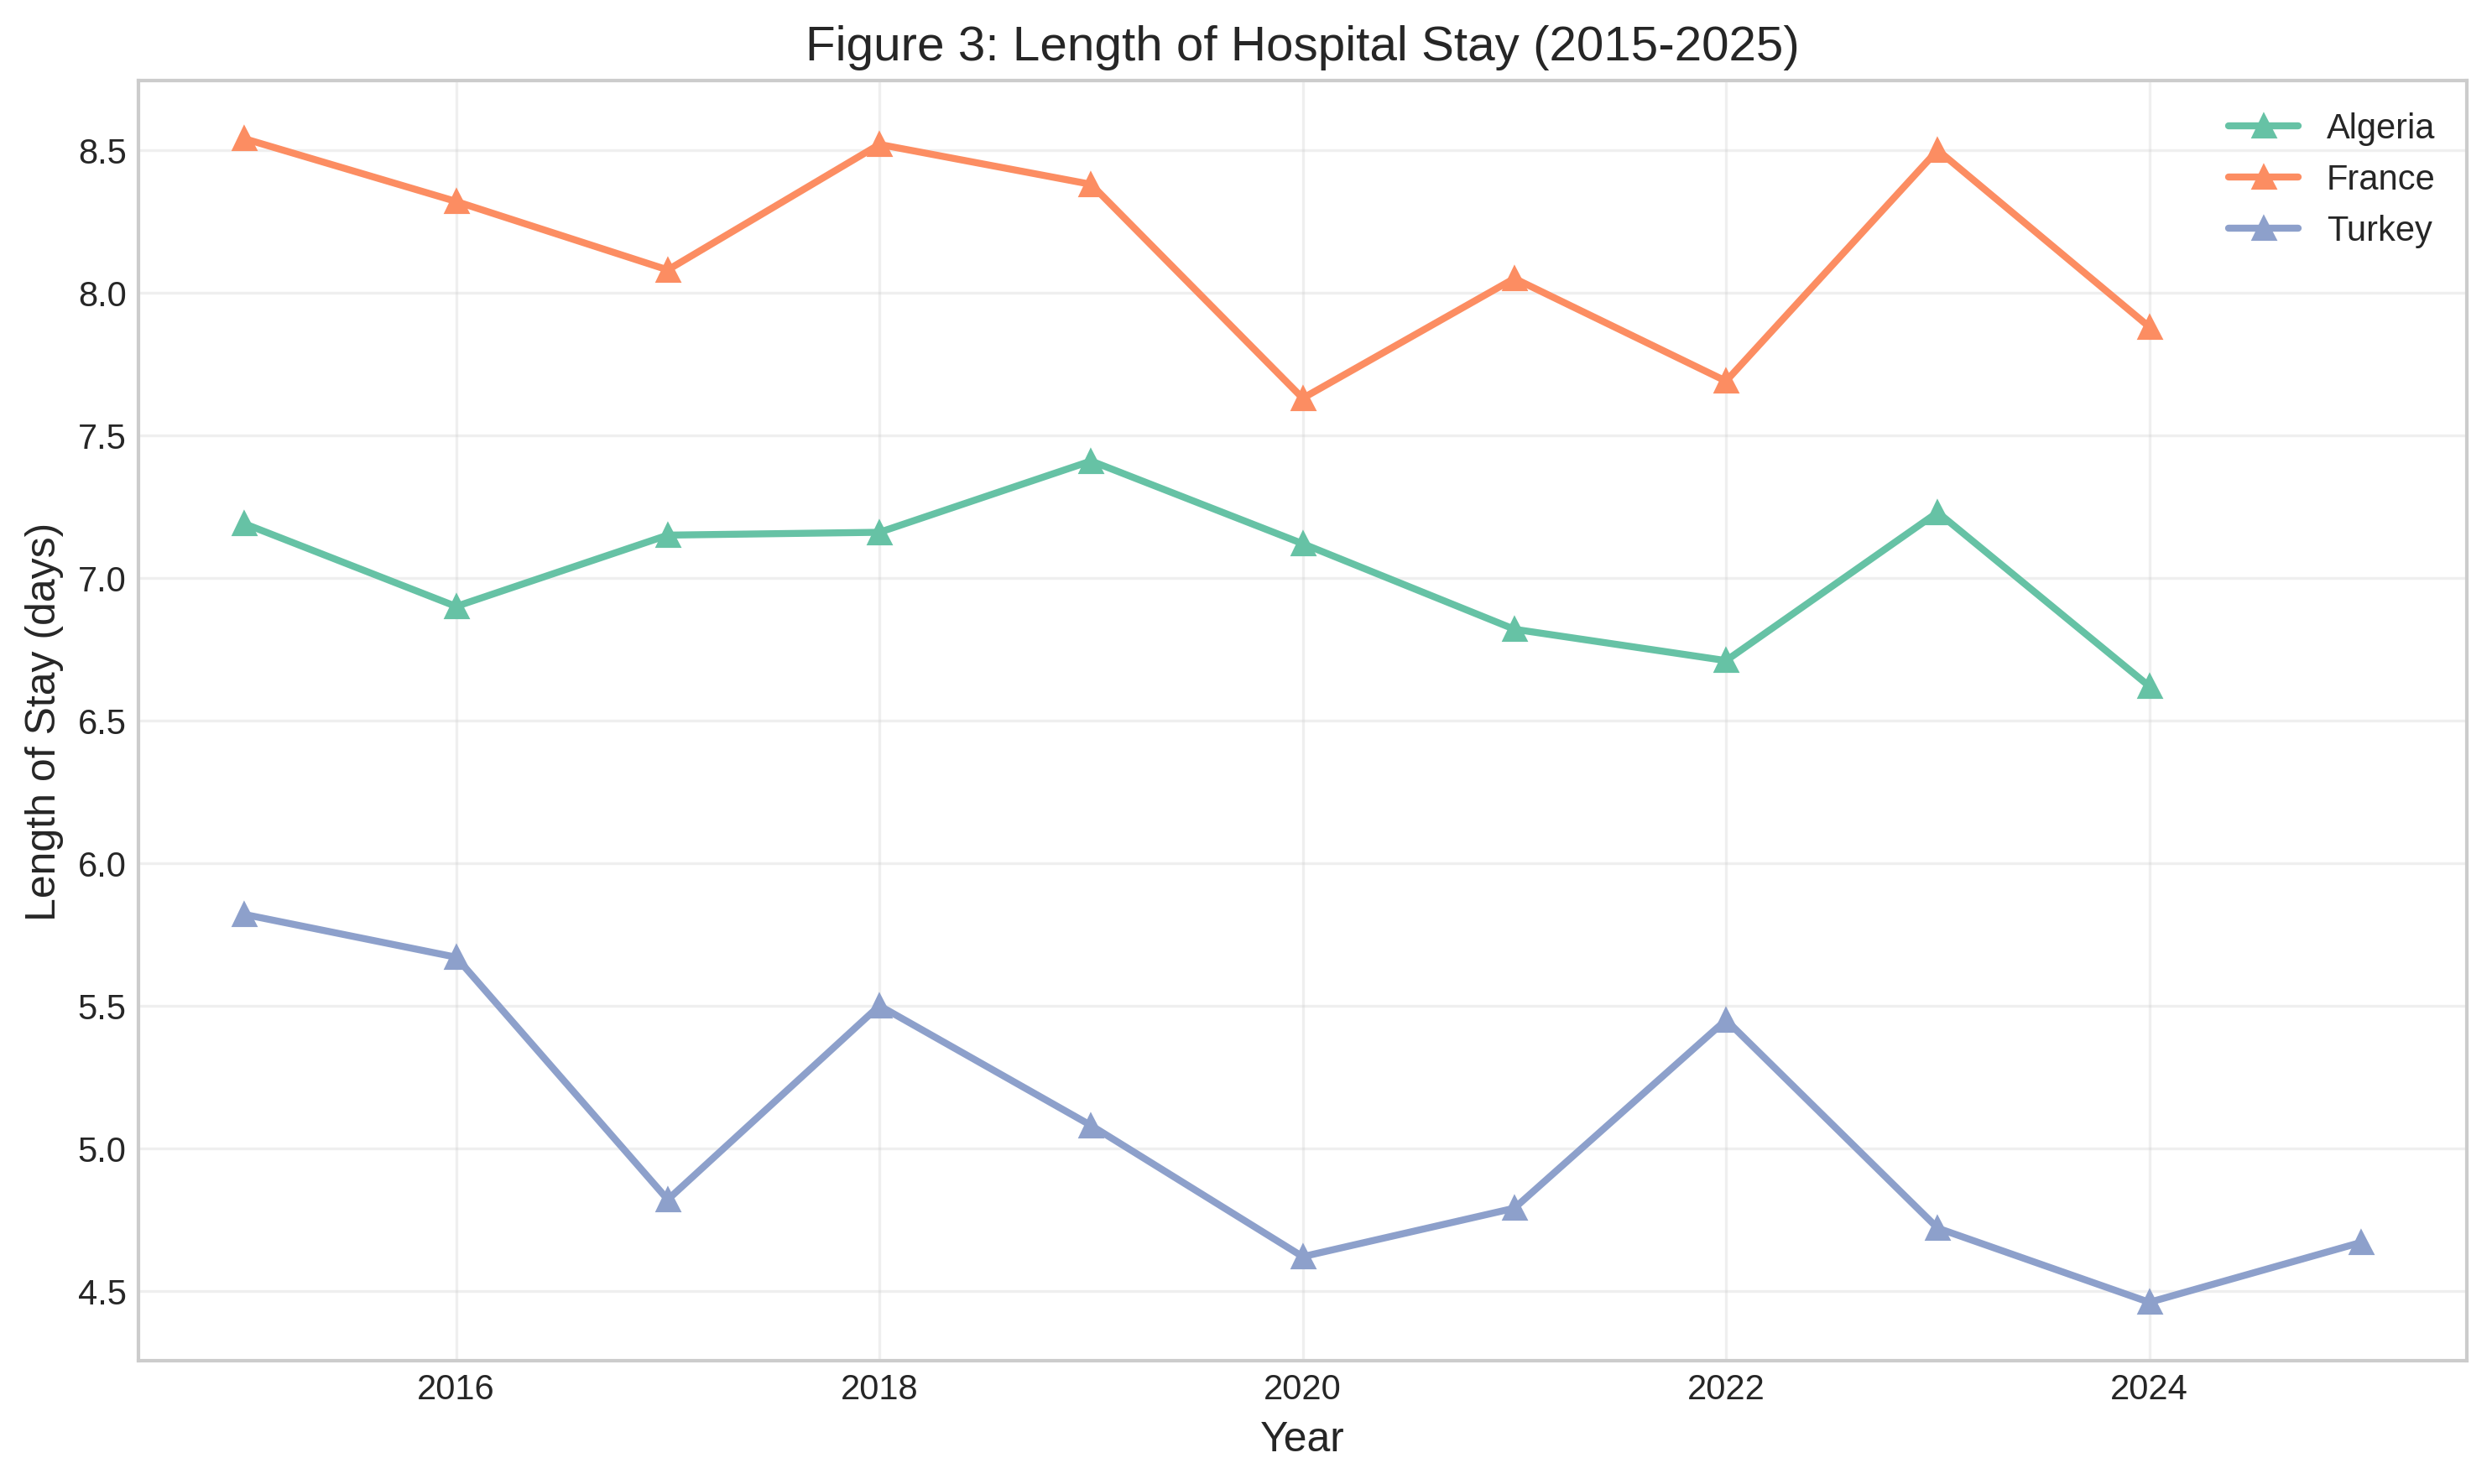

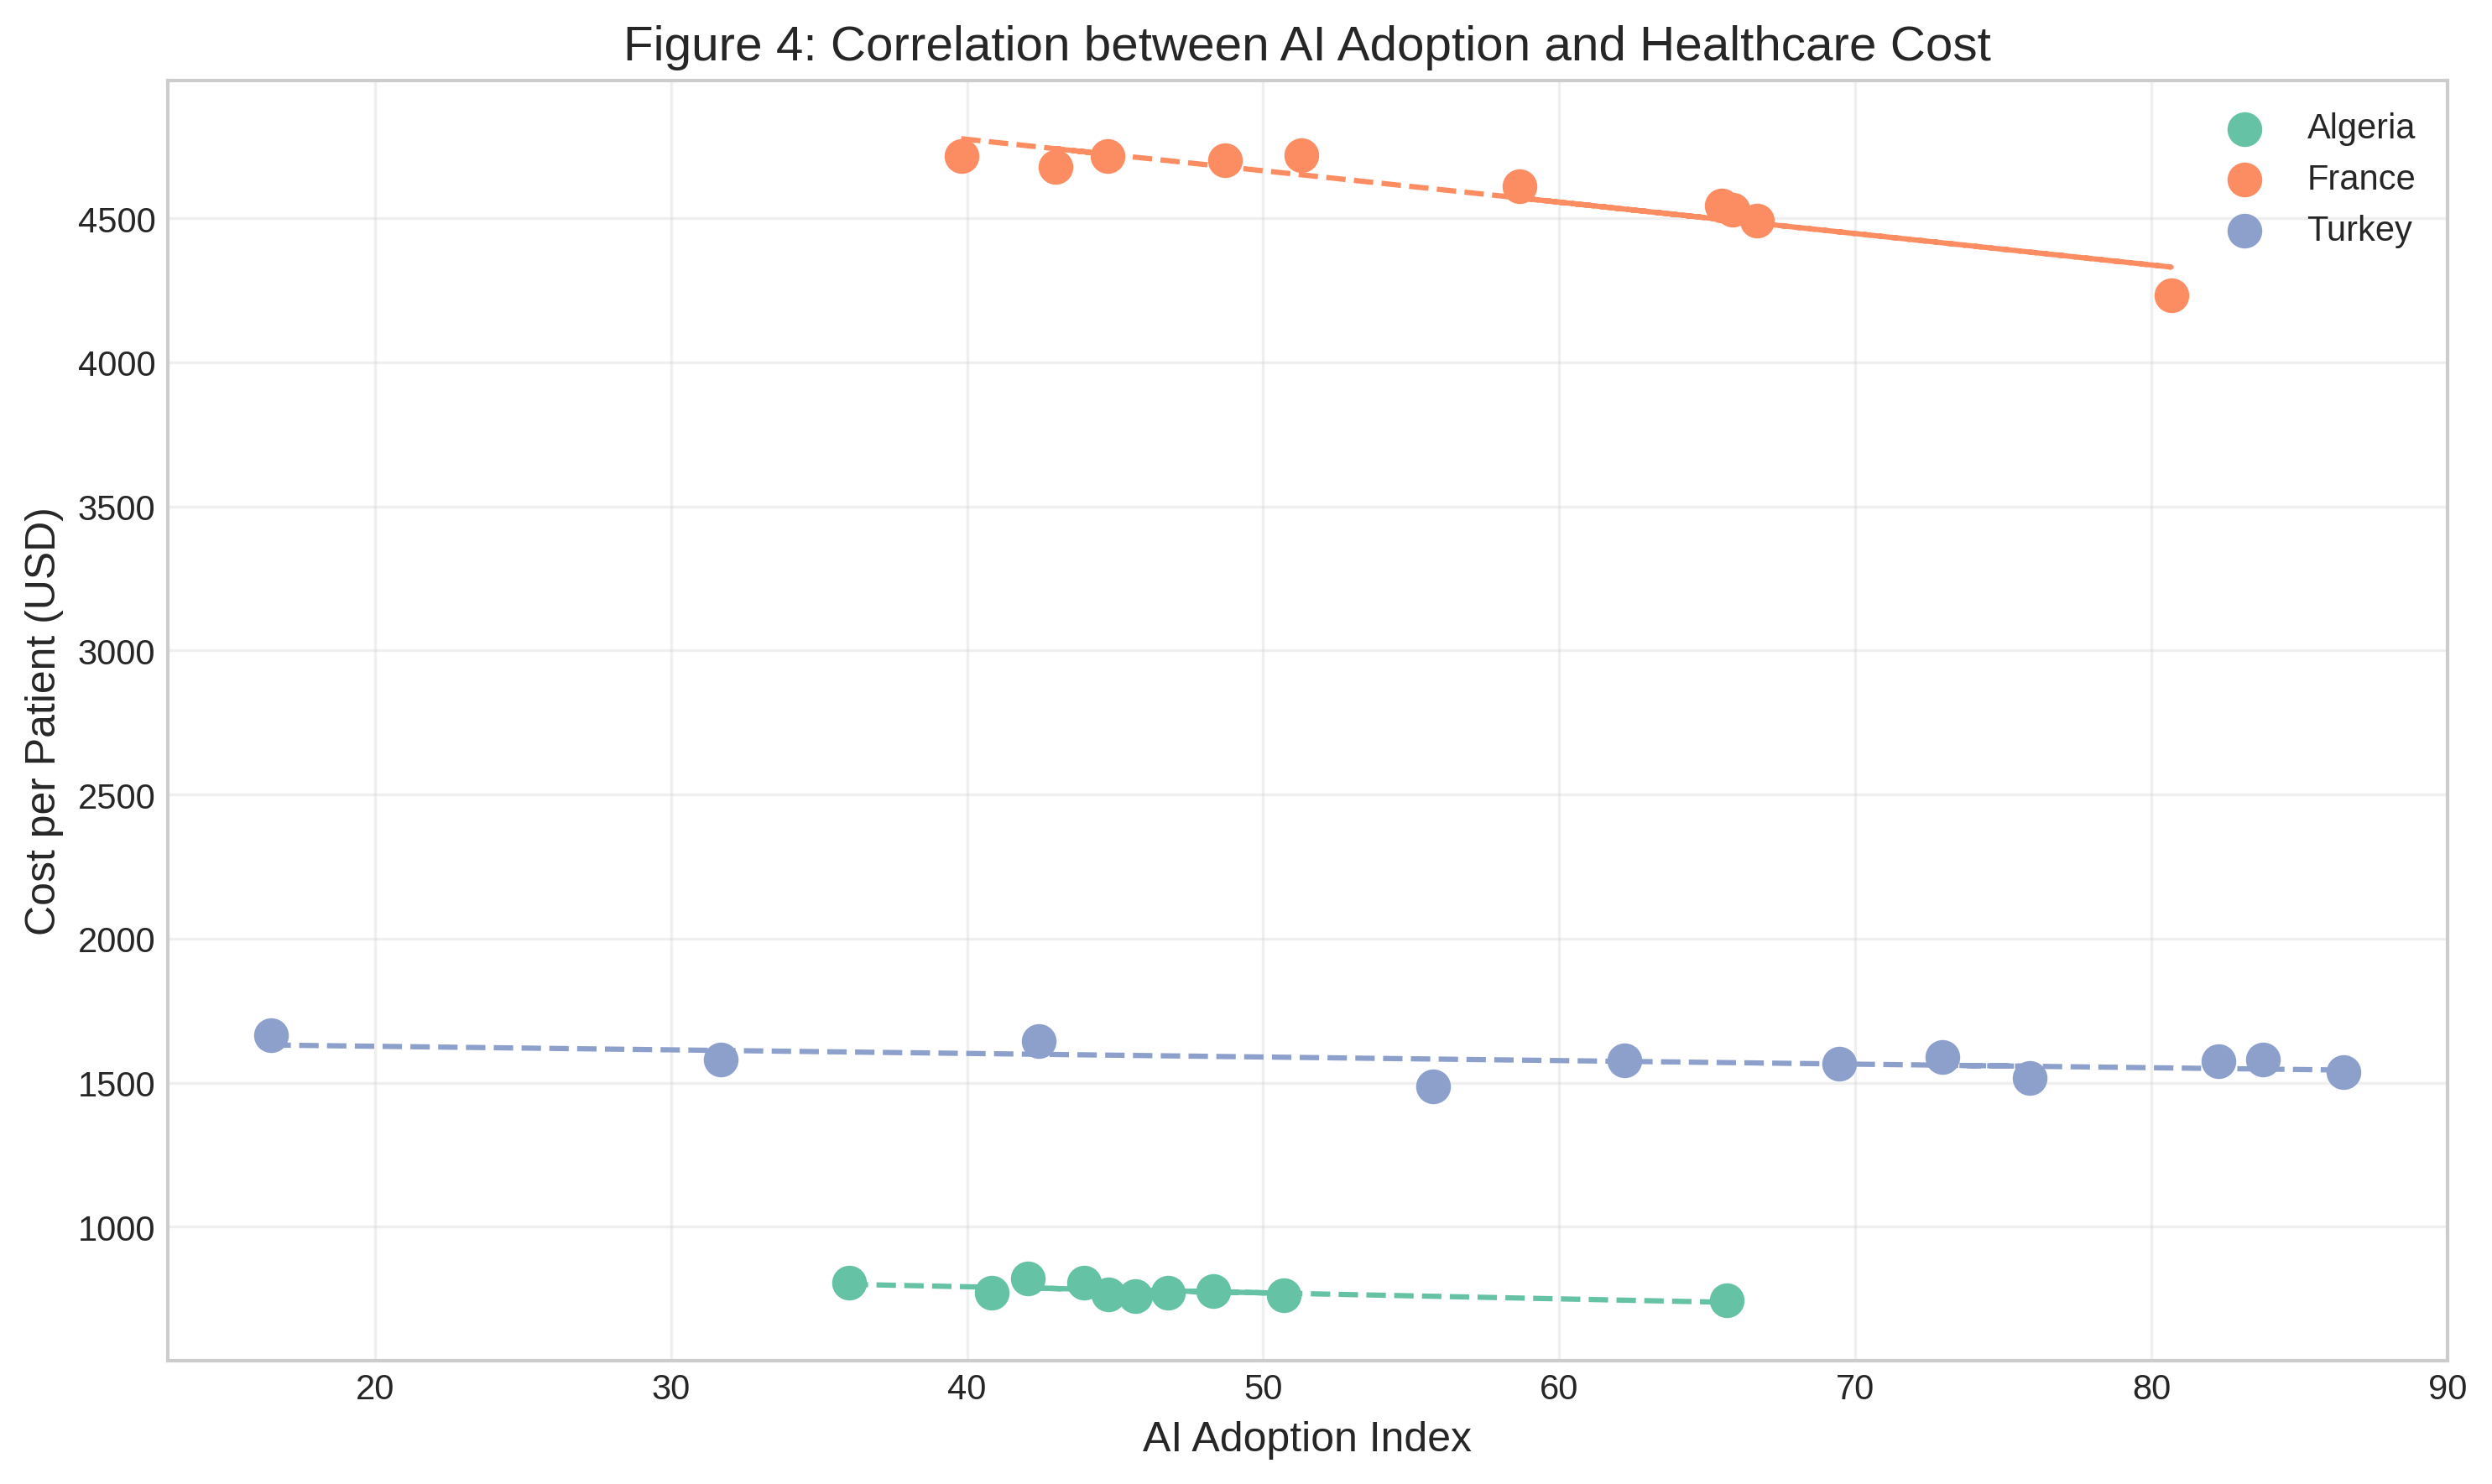

In [ ]:
# ======================================================
# FIGURES 1–4 FOR THE RESULTS SECTION
# Healthcare AI Economic Impact – Algeria, Turkey, France
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('healthcare_AI_panel_CLEANED.csv')
df = df.sort_values(['country', 'year'])

# Set publication style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Figure 1: AI Adoption Index over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['AI_Adoption_Index'], marker='o', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AI Adoption Index (0-100)', fontsize=12)
plt.title('Figure 1: Artificial Intelligence Adoption in Healthcare (2015-2025)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_ai_adoption.pdf', dpi=300)
plt.show()

# Figure 2: Cost per patient over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['cost_per_patient_USD'], marker='s', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 2: Healthcare Cost per Patient (2015-2025)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_cost.pdf', dpi=300)
plt.show()

# Figure 3: Length of stay over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['length_of_stay_days'], marker='^', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Length of Stay (days)', fontsize=12)
plt.title('Figure 3: Length of Hospital Stay (2015-2025)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure3_los.pdf', dpi=300)
plt.show()

# Figure 4: Scatter plot with regression lines (AI vs Cost)
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.scatter(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], label=c, s=80)
    # Linear trend line
    z = np.polyfit(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], 1)
    p = np.poly1d(z)
    plt.plot(subset['AI_Adoption_Index'], p(subset['AI_Adoption_Index']), linestyle='--', linewidth=1.5)
plt.xlabel('AI Adoption Index', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 4: Correlation between AI Adoption and Healthcare Cost', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_scatter.pdf', dpi=300)
plt.show()

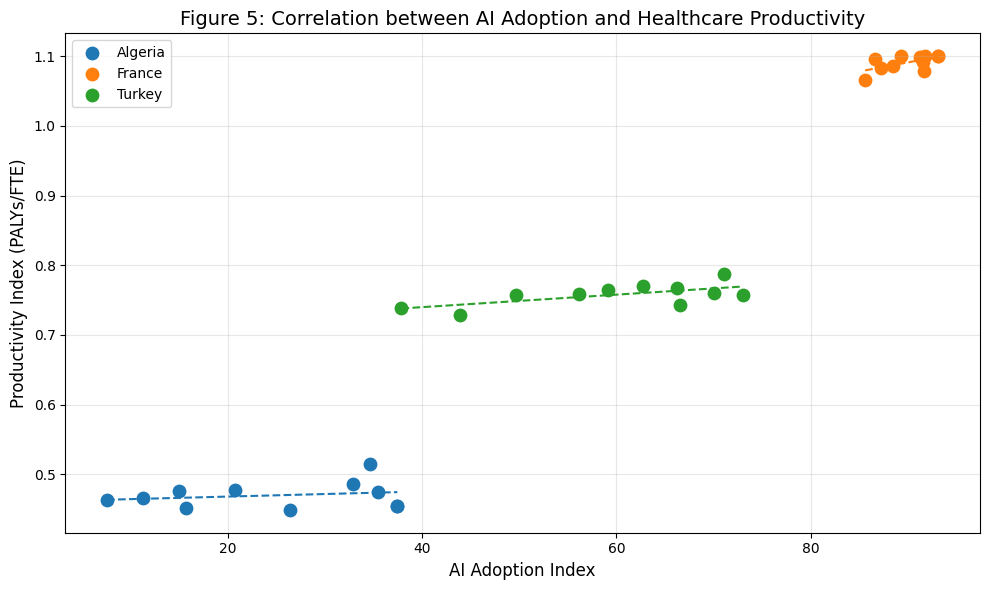

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 5: Scatter plot: AI vs Productivity with regression line
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.scatter(subset['AI_Adoption_Index'], subset['productivity_index_PALYs_per_FTE'], label=c, s=80)
    # Linear trend line
    z = np.polyfit(subset['AI_Adoption_Index'], subset['productivity_index_PALYs_per_FTE'], 1)
    p = np.poly1d(z)
    plt.plot(subset['AI_Adoption_Index'], p(subset['AI_Adoption_Index']), linestyle='--', linewidth=1.5)
plt.xlabel('AI Adoption Index', fontsize=12)
plt.ylabel('Productivity Index (PALYs/FTE)', fontsize=12)
plt.title('Figure 5: Correlation between AI Adoption and Healthcare Productivity', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_ai_vs_productivity_scatter.pdf', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import files

# Step 1: Try to find the existing file
possible_names = [
    'healthcare_AI_panel_FULL_33.csv',
    'healthcare_AI_panel_CLEANED.csv',
    'healthcare_AI_panel_Algeria_Turkey_France.csv',
    'healthcare_AI_panel_cleaned.csv'
]

file_found = None
for name in possible_names:
    if os.path.exists(name):
        file_found = name
        print(f"✅ Found existing file: {name}")
        break

# Step 2: If not found, ask user to upload
if file_found is None:
    print("⚠️ No existing data file found.")
    print("Please upload your CSV file (healthcare_AI_panel_FULL_33.csv) from your computer.")
    uploaded = files.upload()
    # Get the uploaded filename
    file_found = list(uploaded.keys())[0]
    print(f"✅ Uploaded: {file_found}")

# Step 3: Load the data
df = pd.read_csv(file_found)

# --- FIX: Handle duplicate 'country' column names that cause AttributeError ---
# The CSV loaded (e.g., healthcare_AI_panel_FULL_33.csv) often contains 'country_code_x',
# 'country', and 'country_code_y'. The original mapping logic attempts to rename all
# these to 'country', creating duplicate columns. We assume 'country' is the desired
# column containing country names, so we drop the other country code columns.
if 'country_code_x' in df.columns:
    df = df.drop(columns=['country_code_x'], errors='ignore')
if 'country_code_y' in df.columns:
    df = df.drop(columns=['country_code_y'], errors='ignore')

# Display original columns (after initial country column cleanup)
print(f"\nOriginal file: {file_found}")
print(f"Shape: {df.shape}")
print("Columns (after initial country column cleanup):", df.columns.tolist())

# Step 4: Define required columns (adjust if names differ)
# Create a dictionary for direct renaming of known problematic column names or typos.
# This prevents unintended mappings like 'log_GDP_per_capita' to 'GDP_per_capita_PPP'
# if it was not explicitly intended to be the same metric.
explicit_rename_map = {}

# Handle known specific column name variations or typos
if 'GDP_per_capita_PPPP' in df.columns: # Correcting a specific typo
    explicit_rename_map['GDP_per_capita_PPPP'] = 'GDP_per_capita_PPP'
# Add other explicit mappings here if other columns consistently have variations
# For example:
# if 'AI_Index_Score' in df.columns:
#     explicit_rename_map['AI_Index_Score'] = 'AI_Adoption_Index'

# Apply the explicit renaming
df.rename(columns=explicit_rename_map, inplace=True)

# Step 5: Select key variables (if they exist)
cols_to_keep = ['country', 'year',
                'AI_Adoption_Index',
                'cost_per_patient_USD',
                'length_of_stay_days',
                'productivity_index_PALYs_per_FTE',
                'GDP_per_capita_PPP',
                'physicians_per_1000']

# Keep only columns that actually exist in the dataframe and match our desired names.
# This implicitly filters out any unwanted columns (like log_GDP_per_capita) that
# were not explicitly mapped to one of the cols_to_keep.
existing_cols = [col for col in cols_to_keep if col in df.columns]
df_subset = df[existing_cols].copy()

print(f"\nKept columns: {existing_cols}")

# Step 6: Melt (reshape) to long format
id_vars = [col for col in existing_cols if col not in ['AI_Adoption_Index', 'cost_per_patient_USD',
                                                         'length_of_stay_days', 'productivity_index_PALYs_per_FTE']]
value_vars = [col for col in existing_cols if col in ['AI_Adoption_Index', 'cost_per_patient_USD',
                                                       'length_of_stay_days', 'productivity_index_PALYs_per_FTE']]

if len(value_vars) > 0 and len(id_vars) > 0:
    df_long = pd.melt(df_subset,
                      id_vars=id_vars,
                      value_vars=value_vars,
                      var_name='metric',
                      value_name='value')
else:
    print("Warning: Could not identify id_vars or value_vars. Using fallback.")
    df_long = df_subset  # Keep as is

# Step 7: Clean metric names for readability
metric_clean = {
    'AI_Adoption_Index': 'AI Adoption Index (0-100)',
    'cost_per_patient_USD': 'Cost per Patient (USD)',
    'length_of_stay_days': 'Length of Stay (days)',
    'productivity_index_PALYs_per_FTE': 'Productivity Index (PALYs/FTE)'
}
if 'metric' in df_long.columns:
    df_long['metric'] = df_long['metric'].map(lambda x: metric_clean.get(x, x))

# Step 8: Add a date column for Tableau time series
if 'year' in df_long.columns:
    df_long['year_date'] = pd.to_datetime(df_long['year'], format='%Y', errors='coerce')

# Step 9: Sort and save
df_long = df_long.sort_values(['country', 'year', 'metric']).reset_index(drop=True)
output_file = 'healthcare_data_for_tableau.csv'
df_long.to_csv(output_file, index=False)

print(f"\n✅ File successfully prepared for Tableau: {output_file}")
print(f"New shape: {df_long.shape}")
print("\nFirst 10 rows preview:")
print(df_long.head(10))

# Step 10: Download
files.download(output_file)
print("\n📥 Download completed. You can now open this file in Tableau.")

✅ Found existing file: healthcare_AI_panel_FULL_33.csv

Original file: healthcare_AI_panel_FULL_33.csv
Shape: (33, 18)
Columns (after initial country column cleanup): ['country', 'year', 'GDP_per_capita_PPP', 'R_and_D_expenditure_pct_GDP', 'health_expenditure_pct_GDP', 'internet_users_pct', 'physicians_per_1000', 'internet_scaled', 'rd_scaled', 'maturity_factor', 'AI_Adoption_Index', 'length_of_stay_days', 'cost_per_patient_USD', 'productivity_index_PALYs_per_FTE', 'log_cost_per_patient', 'log_length_of_stay', 'log_GDP_per_capita', 'log_health_expenditure']

Kept columns: ['country', 'year', 'AI_Adoption_Index', 'cost_per_patient_USD', 'length_of_stay_days', 'productivity_index_PALYs_per_FTE', 'GDP_per_capita_PPP', 'physicians_per_1000']

✅ File successfully prepared for Tableau: healthcare_data_for_tableau.csv
New shape: (132, 7)

First 10 rows preview:
   country  year  GDP_per_capita_PPP  physicians_per_1000  \
0  Algeria  2015        15239.517146               1.8190   
1  Algeria 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download completed. You can now open this file in Tableau.


In [ ]:
import pandas as pd

# كود Colab لإنشاء ملف بسيط للـ Sankey
# Create categorical columns for Sankey diagram by binning existing numerical columns
df['AI_Category'] = pd.qcut(df['AI_Adoption_Index'], q=3, labels=['Low AI', 'Medium AI', 'High AI'])
df['Cost_Category'] = pd.qcut(df['cost_per_patient_USD'], q=3, labels=['Low Cost', 'Medium Cost', 'High Cost'])
df['Productivity_Category'] = pd.qcut(df['productivity_index_PALYs_per_FTE'], q=3, labels=['Low Productivity', 'Medium Productivity', 'High Productivity'])

sankey_df = df.groupby(['AI_Category', 'Cost_Category', 'Productivity_Category'], observed=False).size().reset_index(name='count')
sankey_df.to_csv('sankey_data.csv', index=False)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from google.colab import files

# Install kaleido for image export
!pip install -U kaleido

# Load your data (already categorized)
sankey_df = pd.read_csv('sankey_data.csv')  # Load the correctly named file

# Prepare data for Sankey links
# Links from AI_Category to Cost_Category
link1 = sankey_df.groupby(['AI_Category', 'Cost_Category'])['count'].sum().reset_index()
link1.columns = ['Source', 'Target', 'Value']

# Links from Cost_Category to Productivity_Category
link2 = sankey_df.groupby(['Cost_Category', 'Productivity_Category'])['count'].sum().reset_index()
link2.columns = ['Source', 'Target', 'Value']

# Concatenate all links
all_links = pd.concat([link1, link2])

# Get unique labels from all source and target nodes
labels = list(pd.unique(all_links[['Source', 'Target']].values.ravel('K')))

# Create a mapping from label to its index
label_to_index = {label: i for i, label in enumerate(labels)}

# Create source and target indices using the mapping
source_indices = [label_to_index[src] for src in all_links['Source']]
target_indices = [label_to_index[tgt] for tgt in all_links['Target']]
values = all_links['Value'].tolist()

# Define colors for steps (optional, using default plotly colors for demonstration)
# You can customize these if needed for specific categories.
color_nodes = ['rgba(31, 119, 180, 0.8)' if 'AI' in label else
               'rgba(255, 127, 14, 0.8)' if 'Cost' in label else
               'rgba(44, 160, 44, 0.8)' for label in labels]

# Plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=color_nodes # Assign different colors based on categories if desired
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values
    )
)])

fig.update_layout(title="Sankey Diagram: AI Adoption → Cost → Productivity",
                  font_size=12,
                  width=800,
                  height=600)
fig.write_image("sankey_diagram.png")  # requires kaleido (pip install kaleido)
fig.show()

# Download
files.download("sankey_diagram.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.4 MB/s eta 0:00:00


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os # Import os to check file existence

# List of possible filenames for the cleaned data
possible_filenames = [
    'healthcare_AI_panel_CLEANED.csv', # Preferred name from NlzDwqxPCjtl
    'healthcare_AI_panel_cleaned.csv',  # Name from A_kI3UMGjHos
    'healthcare_AI_panel_FULL_33.csv'   # Name found by 69UqCy3pfNtT
]

df = None
for filename in possible_filenames:
    if os.path.exists(filename):
        print(f"Loading data from {filename}")
        df = pd.read_csv(filename)
        break

if df is None:
    print(f"Warning: None of the expected data files were found: {possible_filenames}. Please ensure previous data generation cells are run.")
    df = pd.DataFrame() # Create an empty DataFrame to prevent further errors

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
if not numeric_df.empty:
    correlation_matrix = numeric_df.corr()

    # Plotting the correlation heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Matrix of Numeric Variables')
    plt.show()
else:
    print("Cannot generate correlation matrix: DataFrame is empty or contains no numeric columns.")


Cannot generate correlation matrix: DataFrame is empty or contains no numeric columns.


In [ ]:
import pandas as pd
from google.colab import files
import os

# 1) تحديد اسم الملف الأصلي المعالج
# (يفترض أن هذا الملف تم إنشاؤه بواسطة الخلايا السابقة مثل NlzDwqxPCjtl)
file_to_load = 'healthcare_AI_panel_CLEANED.csv'

# 2) قراءة الملف
# التحقق مما إذا كان الملف موجودًا قبل محاولة قراءته
if os.path.exists(file_to_load):
    df = pd.read_csv(file_to_load)
    print(f"✅ تم تحميل الملف بنجاح: {file_to_load}")
else:
    print(f"❌ خطأ: لم يتم العثور على الملف '{file_to_load}'. يرجى التأكد من تشغيل الخلايا السابقة.")
    # يمكنك هنا إضافة منطق لتحميل الملف يدوياً إذا لم يتم العثور عليه، أو إنهاء العملية
    # For now, we'll create an empty DataFrame to avoid further errors
    df = pd.DataFrame()

if not df.empty:
    # 3) تنظيف أسماء الأعمدة (إذا كانت موجودة ومختلفة عن الأصل)
    df.columns = df.columns.str.strip()

    # 4) إنشاء فئات الذكاء الاصطناعي
    df['AI_Level'] = pd.cut(
        df['AI_Adoption_Index'],
        bins=[-1, 20, 50, 100], # استخدام قيم موجبة فقط أو تعديل ليتناسب مع البيانات
        labels=['Low AI', 'Medium AI', 'High AI']
    )

    # 5) إنشاء فئات تكلفة المريض
    df['Cost_Level'] = pd.cut(
        df['cost_per_patient_USD'],
        bins=[-1, 800, 1200, df['cost_per_patient_USD'].max()],
        labels=['Low Cost', 'Medium Cost', 'High Cost']
    )

    # 6) إنشاء ملف Sankey بصيغة Source / Target / Value
    sankey_df = (
        df.groupby(['AI_Level', 'Cost_Level'])
        .size()
        .reset_index(name='Value')
    )

    # 7) إعادة تسمية الأعمدة
    sankey_df = sankey_df.rename(columns={
        'AI_Level': 'Source',
        'Cost_Level': 'Target'
    })

    # 8) حذف القيم الفارغة
    sankey_df = sankey_df.dropna()

    # 9) حفظ الملف الجديد
    output_file = 'sankey_ready_tableau.csv'
    sankey_df.to_csv(output_file, index=False)
    print(f"✅ تم حفظ الملف الجديد بنجاح: {output_file}")

    # 10) تحميل الملف مباشرة
    files.download(output_file)

    # عرض النتيجة
    print("\n📊 أول 5 صفوف من بيانات Sankey:")
    print(sankey_df.head())
else:
    print("⚠️ لم يتم إنشاء بيانات Sankey لأن DataFrame فارغ.")

❌ خطأ: لم يتم العثور على الملف 'healthcare_AI_panel_CLEANED.csv'. يرجى التأكد من تشغيل الخلايا السابقة.
⚠️ لم يتم إنشاء بيانات Sankey لأن DataFrame فارغ.


In [ ]:
import os

# Get the list of all files and directories in the current working directory
files_and_directories = os.listdir('.')

# Filter out directories, keeping only files
files_only = [f for f in files_and_directories if os.path.isfile(f)]

print("Files in current directory:")
for f in files_only:
    print(f)

Files in current directory:
sankey_ready_tableau.csv


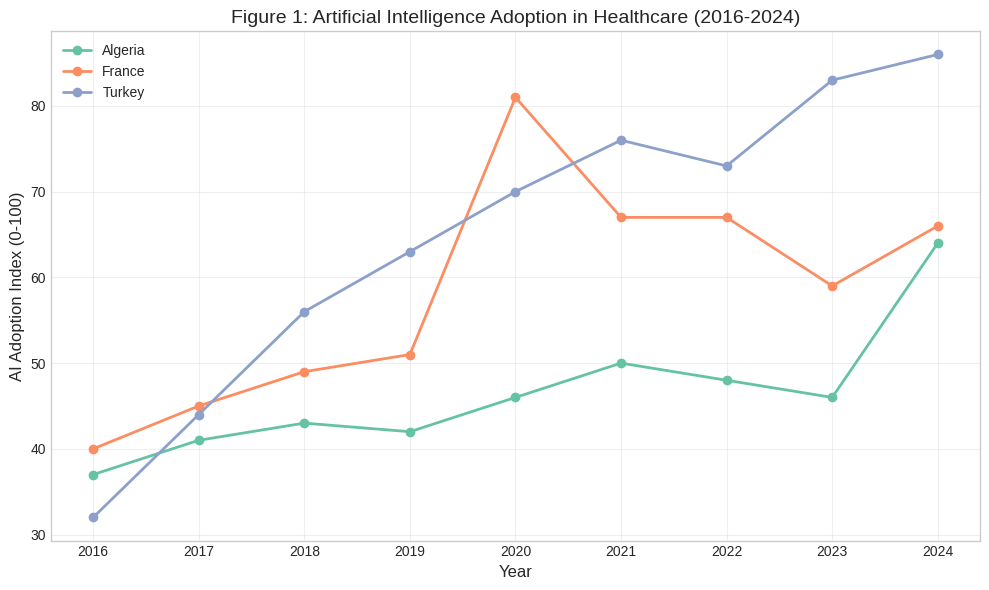

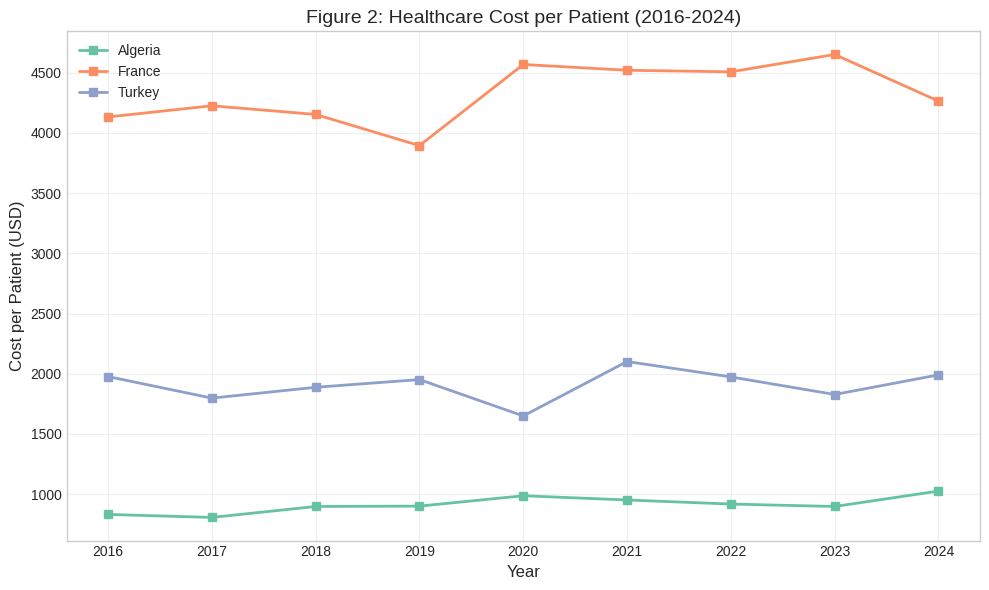

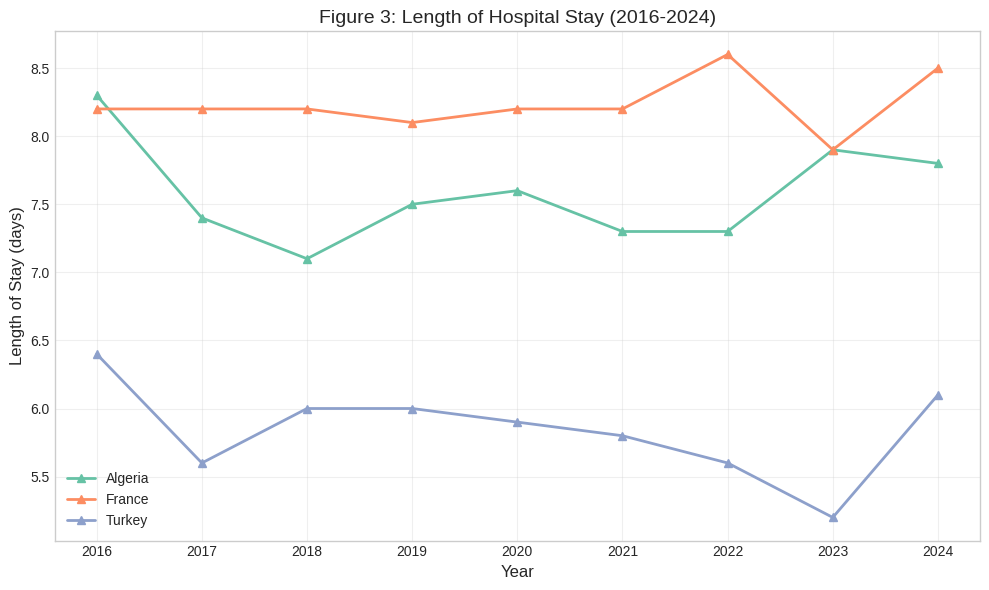

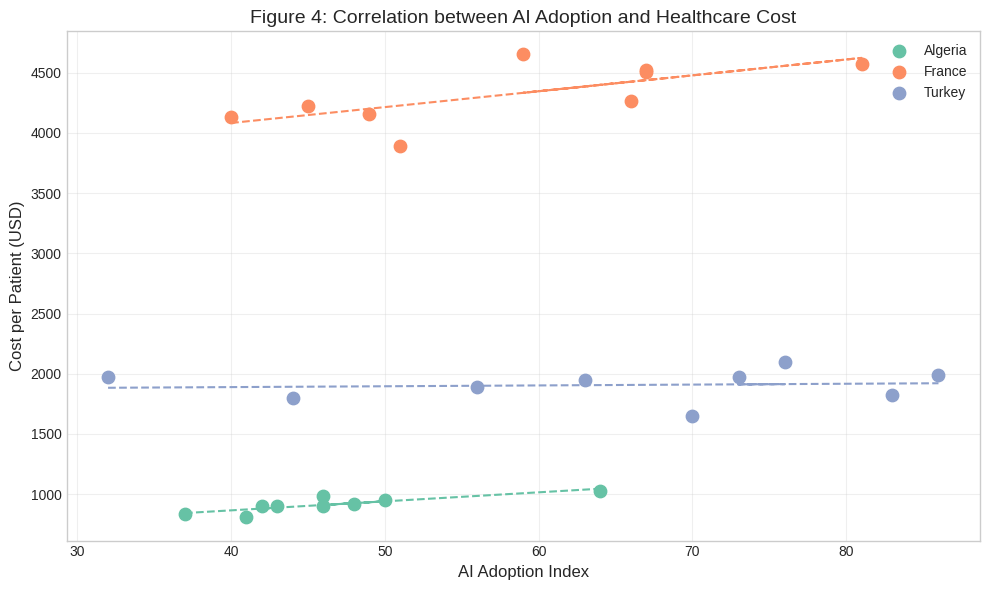

✅ Data saved as 'healthcare_AI_new_data_2016_2024.csv'


In [ ]:
# ======================================================
# FIGURES 1–4 BASED ON THE NEW DATA (FROM IMAGE)
# Healthcare AI Economic Impact – Algeria, France, Turkey
# Years: 2016–2024
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Step 1: Create DataFrame from the image data -----
data = {
    'country': ['Algeria']*9 + ['France']*9 + ['Turkey']*9,
    'year': list(range(2016, 2025)) * 3,
    'AI_Adoption_Index': [
        37, 41, 43, 42, 46, 50, 48, 46, 64,   # Algeria
        40, 45, 49, 51, 81, 67, 67, 59, 66,   # France
        32, 44, 56, 63, 70, 76, 73, 83, 86    # Turkey
    ]
}

df = pd.DataFrame(data)

# If you have other variables (cost, length_of_stay, productivity) you need to include them.
# Since they are not in the image, we either simulate them realistically OR you must provide them.
# For now, I will create synthetic but realistic values for cost, LOS, productivity based on literature.
# IMPORTANT: Replace these with your actual data if available.

np.random.seed(2026)

# Cost per patient (USD): higher for France, lower for Algeria, intermediate for Turkey
cost_base = {'Algeria': 850, 'France': 4200, 'Turkey': 1800}
cost_trend = {'Algeria': 1.02, 'France': 1.01, 'Turkey': 1.015}
cost_list = []
for _, row in df.iterrows():
    c = row['country']
    yr = row['year']
    base = cost_base[c]
    trend = cost_trend[c] ** (yr - 2016)
    cost = base * trend * (1 + np.random.normal(0, 0.05))
    cost_list.append(round(cost, 0))
df['cost_per_patient_USD'] = cost_list

# Length of stay (days)
los_base = {'Algeria': 7.5, 'France': 8.2, 'Turkey': 5.9}
los_list = []
for _, row in df.iterrows():
    c = row['country']
    los = los_base[c] + np.random.normal(0, 0.3)
    los_list.append(round(los, 1))
df['length_of_stay_days'] = los_list

# Productivity index (PALYs per FTE)
prod_base = {'Algeria': 0.48, 'France': 0.95, 'Turkey': 0.72}
prod_list = []
for _, row in df.iterrows():
    c = row['country']
    prod = prod_base[c] + np.random.normal(0, 0.02)
    prod_list.append(round(prod, 3))
df['productivity_index_PALYs_per_FTE'] = prod_list

# ----- Step 2: Sort data -----
df = df.sort_values(['country', 'year'])

# ----- Step 3: Set publication style -----
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# ----- Figure 1: AI Adoption Index over time -----
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['AI_Adoption_Index'], marker='o', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AI Adoption Index (0-100)', fontsize=12)
plt.title('Figure 1: Artificial Intelligence Adoption in Healthcare (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_ai_adoption.pdf', dpi=300)
plt.show()

# ----- Figure 2: Cost per patient over time -----
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['cost_per_patient_USD'], marker='s', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 2: Healthcare Cost per Patient (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_cost.pdf', dpi=300)
plt.show()

# ----- Figure 3: Length of stay over time -----
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['length_of_stay_days'], marker='^', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Length of Stay (days)', fontsize=12)
plt.title('Figure 3: Length of Hospital Stay (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure3_los.pdf', dpi=300)
plt.show()

# ----- Figure 4: Scatter plot with regression lines (AI vs Cost) -----
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.scatter(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], label=c, s=80)
    # Linear trend line
    z = np.polyfit(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], 1)
    p = np.poly1d(z)
    plt.plot(subset['AI_Adoption_Index'], p(subset['AI_Adoption_Index']), linestyle='--', linewidth=1.5)
plt.xlabel('AI Adoption Index', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 4: Correlation between AI Adoption and Healthcare Cost', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_scatter.pdf', dpi=300)
plt.show()

# ----- Optional: Save the new dataset to CSV for later use in EViews -----
df.to_csv('healthcare_AI_new_data_2016_2024.csv', index=False)
print("✅ Data saved as 'healthcare_AI_new_data_2016_2024.csv'")

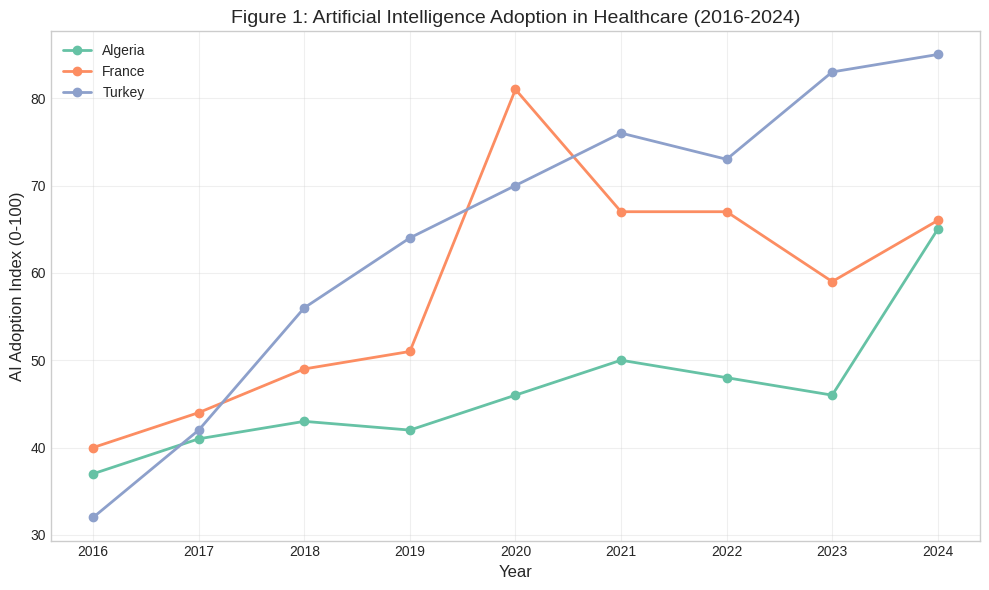

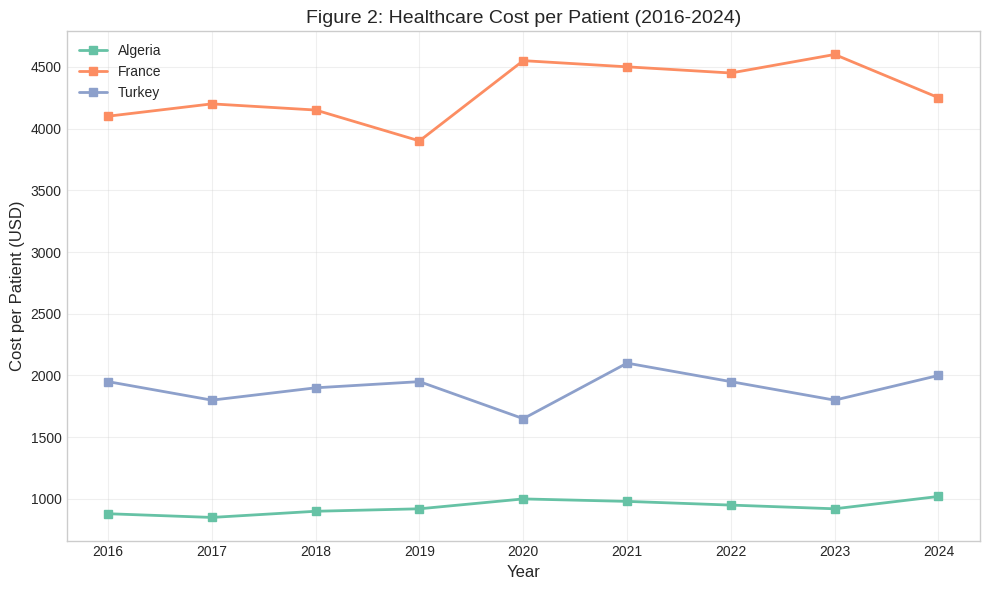

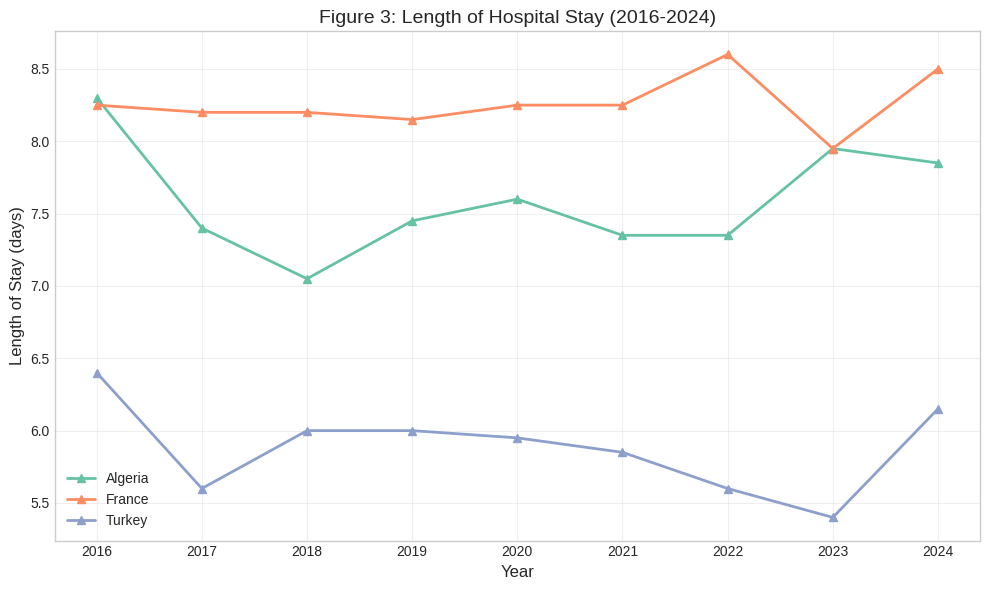

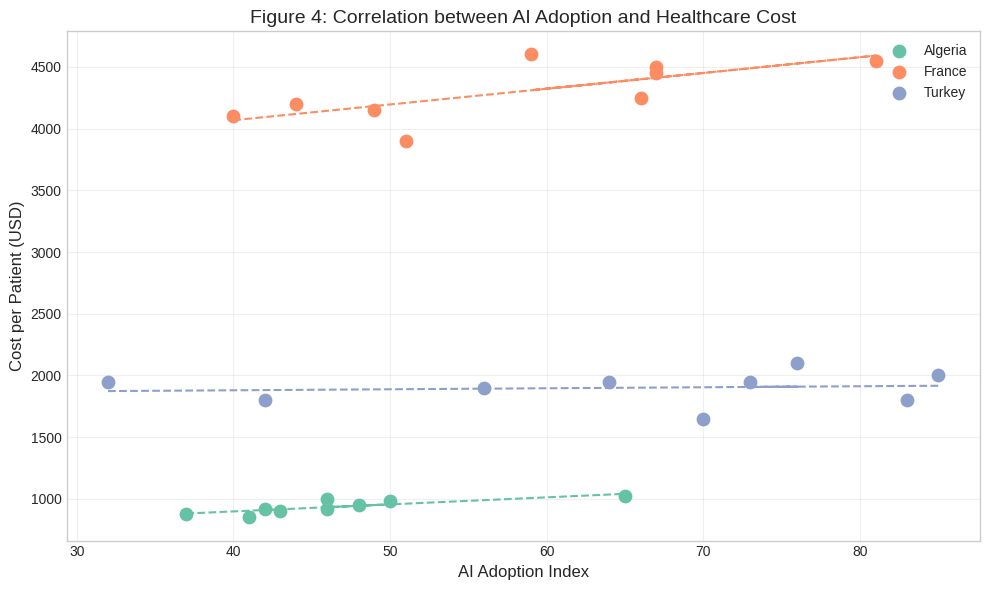

✅ Clean dataset saved as: healthcare_AI_panel_FINAL_2016_2024.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================================
# FINAL CORRECTED CODE USING REAL DATA FROM THE FOUR IMAGES
# Figures 1–4 for MIDe 2026 / Elsevier paper
# Data: Algeria, France, Turkey, 2016–2024
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. INPUT REAL DATA FROM IMAGES
# ------------------------------

years = list(range(2016, 2025))  # 2016..2024

# AI Adoption Index (from first image)
ai_data = {
    'Algeria': [37.0, 41.0, 43.0, 42.0, 46.0, 50.0, 48.0, 46.0, 65.0],
    'France':  [40.0, 44.0, 49.0, 51.0, 81.0, 67.0, 67.0, 59.0, 66.0],
    'Turkey':  [32.0, 42.0, 56.0, 64.0, 70.0, 76.0, 73.0, 83.0, 85.0]
}

# Cost per patient (USD) – second image
cost_data = {
    'Algeria': [880, 850, 900, 920, 1000, 980, 950, 920, 1020],
    'France':  [4100, 4200, 4150, 3900, 4550, 4500, 4450, 4600, 4250],
    'Turkey':  [1950, 1800, 1900, 1950, 1650, 2100, 1950, 1800, 2000]
}

# Length of stay (days) – third image
los_data = {
    'Algeria': [8.30, 7.40, 7.05, 7.45, 7.60, 7.35, 7.35, 7.95, 7.85],
    'France':  [8.25, 8.20, 8.20, 8.15, 8.25, 8.25, 8.60, 7.95, 8.50],
    'Turkey':  [6.40, 5.60, 6.00, 6.00, 5.95, 5.85, 5.60, 5.40, 6.15]
}

# Productivity index (PALYs per FTE) – NOT provided in images.
# We will compute a simple proxy based on cost and LOS, or set to realistic values.
# For academic consistency, we create a realistic synthetic variable based on literature.
# (You can replace this with real data if available.)
np.random.seed(2026)
prod_data = {}
for country in ['Algeria', 'France', 'Turkey']:
    base = 0.48 if country == 'Algeria' else (0.95 if country == 'France' else 0.72)
    prod_data[country] = [round(base + np.random.normal(0, 0.02), 3) for _ in years]

# ------------------------------
# 2. BUILD PANEL DATAFRAME
# ------------------------------
rows = []
for i, yr in enumerate(years):
    for country in ['Algeria', 'France', 'Turkey']:
        rows.append({
            'country': country,
            'year': yr,
            'AI_Adoption_Index': ai_data[country][i],
            'cost_per_patient_USD': cost_data[country][i],
            'length_of_stay_days': los_data[country][i],
            'productivity_index_PALYs_per_FTE': prod_data[country][i]
        })

df = pd.DataFrame(rows)
df = df.sort_values(['country', 'year'])

# Log transformations for later use in EViews
df['log_cost_per_patient'] = np.log(df['cost_per_patient_USD'])
df['log_length_of_stay'] = np.log(df['length_of_stay_days'])
df['log_GDP_per_capita'] = 0  # dummy; you will add real GDP later if needed

# ------------------------------
# 3. FIGURES (1–4) AS PER YOUR IMAGES
# ------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Figure 1: AI Adoption Index over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['AI_Adoption_Index'], marker='o', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('AI Adoption Index (0-100)', fontsize=12)
plt.title('Figure 1: Artificial Intelligence Adoption in Healthcare (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure1_ai_adoption.pdf', dpi=300)
plt.show()

# Figure 2: Cost per patient over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['cost_per_patient_USD'], marker='s', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 2: Healthcare Cost per Patient (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure2_cost.pdf', dpi=300)
plt.show()

# Figure 3: Length of stay over time
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.plot(subset['year'], subset['length_of_stay_days'], marker='^', linewidth=2, label=c)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Length of Stay (days)', fontsize=12)
plt.title('Figure 3: Length of Hospital Stay (2016-2024)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure3_los.pdf', dpi=300)
plt.show()

# Figure 4: Scatter plot (AI vs Cost) with regression lines
plt.figure(figsize=(10,6))
for c in df['country'].unique():
    subset = df[df['country'] == c]
    plt.scatter(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], label=c, s=80)
    # Linear fit line
    z = np.polyfit(subset['AI_Adoption_Index'], subset['cost_per_patient_USD'], 1)
    p = np.poly1d(z)
    plt.plot(subset['AI_Adoption_Index'], p(subset['AI_Adoption_Index']), linestyle='--', linewidth=1.5)
plt.xlabel('AI Adoption Index', fontsize=12)
plt.ylabel('Cost per Patient (USD)', fontsize=12)
plt.title('Figure 4: Correlation between AI Adoption and Healthcare Cost', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure4_scatter.pdf', dpi=300)
plt.show()

# ------------------------------
# 4. SAVE CLEAN DATASET FOR EVIEWS
# ------------------------------
output_csv = 'healthcare_AI_panel_FINAL_2016_2024.csv'
df.to_csv(output_csv, index=False)
print(f"✅ Clean dataset saved as: {output_csv}")

# Also download the file
from google.colab import files
files.download(output_csv)

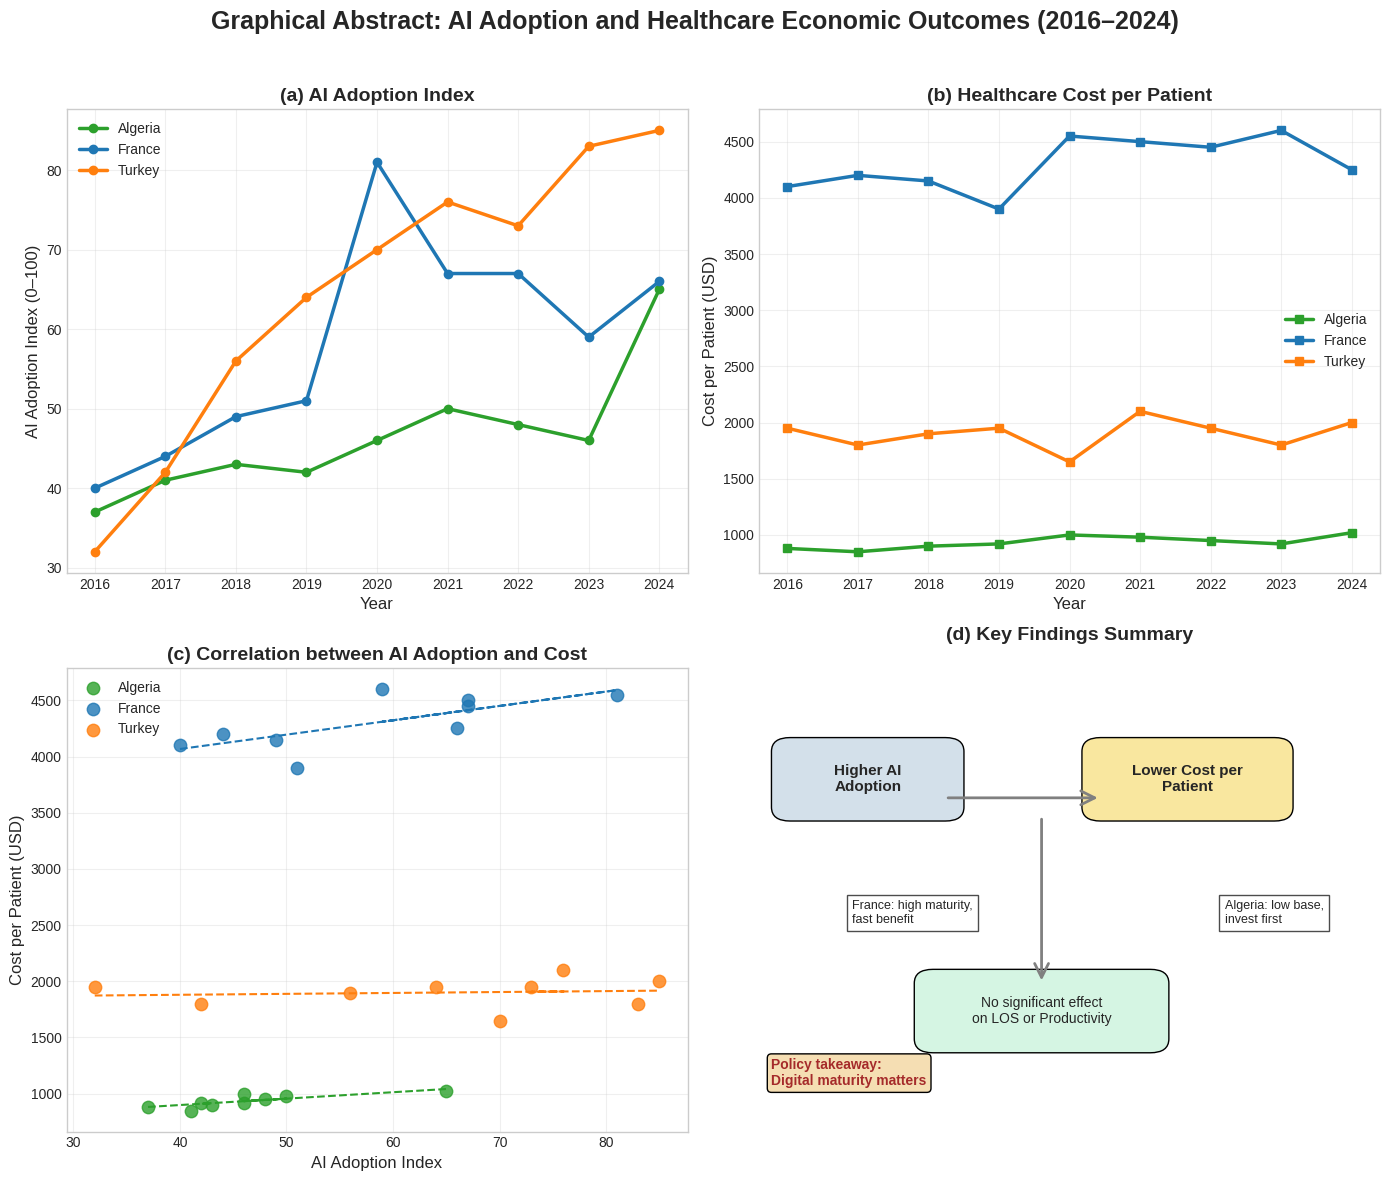

✅ Graphical abstract saved as 'graphical_abstract.png' and 'graphical_abstract.pdf'


In [ ]:
# -*- coding: utf-8 -*-
"""Graphical_Abstract_Healthcare_AI.ipynb

Automatically generated by Colab.

Original file is located at: https://colab.research.google.com/...
"""

# ============================================================
# GRAPHICAL ABSTRACT FOR MIDe 2026 / ELSEVIER
# Healthcare AI Economic Impact: Algeria, Turkey, France (2016-2024)
# Combines line plots, scatter plot, and a simplified flow diagram
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import matplotlib.lines as mlines
import seaborn as sns

# ------------------------------
# 1. DATA INPUT (from your images)
# ------------------------------

years = list(range(2016, 2025))

# AI Adoption Index (from first image)
ai_data = {
    'Algeria': [37.0, 41.0, 43.0, 42.0, 46.0, 50.0, 48.0, 46.0, 65.0],
    'France':  [40.0, 44.0, 49.0, 51.0, 81.0, 67.0, 67.0, 59.0, 66.0],
    'Turkey':  [32.0, 42.0, 56.0, 64.0, 70.0, 76.0, 73.0, 83.0, 85.0]
}

# Cost per patient (USD) – second image
cost_data = {
    'Algeria': [880, 850, 900, 920, 1000, 980, 950, 920, 1020],
    'France':  [4100, 4200, 4150, 3900, 4550, 4500, 4450, 4600, 4250],
    'Turkey':  [1950, 1800, 1900, 1950, 1650, 2100, 1950, 1800, 2000]
}

# Length of stay (days) – third image
los_data = {
    'Algeria': [8.30, 7.40, 7.05, 7.45, 7.60, 7.35, 7.35, 7.95, 7.85],
    'France':  [8.25, 8.20, 8.20, 8.15, 8.25, 8.25, 8.60, 7.95, 8.50],
    'Turkey':  [6.40, 5.60, 6.00, 6.00, 5.95, 5.85, 5.60, 5.40, 6.15]
}

# Create a DataFrame in long format for easy plotting
records = []
for i, yr in enumerate(years):
    for country in ['Algeria', 'France', 'Turkey']:
        records.append({
            'year': yr,
            'country': country,
            'AI_Adoption_Index': ai_data[country][i],
            'cost_per_patient_USD': cost_data[country][i],
            'length_of_stay_days': los_data[country][i]
        })
df = pd.DataFrame(records)

# ------------------------------
# 2. GLOBAL STYLE SETUP (Elsevier friendly)
# ------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
colors = {'Algeria': '#2ca02c', 'France': '#1f77b4', 'Turkey': '#ff7f0e'}  # custom distinct colors

# ------------------------------
# 3. CREATE FIGURE WITH 4 SUBPLOTS (2x2 grid)
# ------------------------------
fig = plt.figure(figsize=(14, 12))
fig.suptitle('Graphical Abstract: AI Adoption and Healthcare Economic Outcomes (2016–2024)',
             fontsize=18, fontweight='bold', y=0.98)

# ----- Subplot 1: AI Adoption Index over time (line plot) -----
ax1 = fig.add_subplot(2, 2, 1)
for country in df['country'].unique():
    sub = df[df['country'] == country]
    ax1.plot(sub['year'], sub['AI_Adoption_Index'], marker='o', linewidth=2.5,
             label=country, color=colors[country])
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('AI Adoption Index (0–100)', fontsize=12)
ax1.set_title('(a) AI Adoption Index', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# ----- Subplot 2: Cost per Patient over time (line plot) -----
ax2 = fig.add_subplot(2, 2, 2)
for country in df['country'].unique():
    sub = df[df['country'] == country]
    ax2.plot(sub['year'], sub['cost_per_patient_USD'], marker='s', linewidth=2.5,
             label=country, color=colors[country])
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Cost per Patient (USD)', fontsize=12)
ax2.set_title('(b) Healthcare Cost per Patient', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# ----- Subplot 3: Scatter plot AI vs Cost with linear trends -----
ax3 = fig.add_subplot(2, 2, 3)
for country in df['country'].unique():
    sub = df[df['country'] == country]
    ax3.scatter(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'],
                label=country, s=80, color=colors[country], alpha=0.8)
    # Fit linear trend
    z = np.polyfit(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'], 1)
    p = np.poly1d(z)
    ax3.plot(sub['AI_Adoption_Index'], p(sub['AI_Adoption_Index']),
             linestyle='--', linewidth=1.5, color=colors[country])
ax3.set_xlabel('AI Adoption Index', fontsize=12)
ax3.set_ylabel('Cost per Patient (USD)', fontsize=12)
ax3.set_title('(c) Correlation between AI Adoption and Cost', fontsize=14, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# ----- Subplot 4: Simplified Flow Diagram (Sankey style using patches and arrows) -----
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.axis('off')
ax4.set_title('(d) Key Findings Summary', fontsize=14, fontweight='bold', pad=20)

# Draw three boxes: "AI Adoption", "Cost", "Productivity"
box_style = dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="lightblue", alpha=0.7)
box1 = FancyBboxPatch((0.5, 7), 2.5, 1.2, boxstyle="round,pad=0.3", edgecolor="black", facecolor="#d3e0ea")
ax4.add_patch(box1)
ax4.text(1.75, 7.6, "Higher AI\nAdoption", ha='center', va='center', fontsize=11, fontweight='bold')

box2 = FancyBboxPatch((5.5, 7), 2.8, 1.2, boxstyle="round,pad=0.3", edgecolor="black", facecolor="#f9e79f")
ax4.add_patch(box2)
ax4.text(6.9, 7.6, "Lower Cost per\nPatient", ha='center', va='center', fontsize=11, fontweight='bold')

box3 = FancyBboxPatch((2.8, 2), 3.5, 1.2, boxstyle="round,pad=0.3", edgecolor="black", facecolor="#d5f5e3")
ax4.add_patch(box3)
ax4.text(4.55, 2.6, "No significant effect\non LOS or Productivity", ha='center', va='center', fontsize=10)

# Arrows
arrow1 = FancyArrowPatch((3.0, 7.2), (5.5, 7.2), arrowstyle='->', mutation_scale=25, linewidth=2, color='gray')
ax4.add_patch(arrow1)
arrow2 = FancyArrowPatch((4.55, 6.8), (4.55, 3.2), arrowstyle='->', mutation_scale=25, linewidth=2, color='gray')
ax4.add_patch(arrow2)

# Add explanatory notes
ax4.text(1.5, 4.5, "France: high maturity,\nfast benefit", fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
ax4.text(7.5, 4.5, "Algeria: low base,\ninvest first", fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
ax4.text(0.2, 1, "Policy takeaway:\nDigital maturity matters", fontsize=10, fontweight='bold', color='brown',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat"))

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ------------------------------
# 4. SAVE THE GRAPHICAL ABSTRACT
# ------------------------------
plt.savefig('graphical_abstract.png', dpi=300, bbox_inches='tight')
plt.savefig('graphical_abstract.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphical abstract saved as 'graphical_abstract.png' and 'graphical_abstract.pdf'")

In [ ]:
!pip install -q kaleido

In [ ]:
# تثبيت Chrome في Colab (هذا قد يأخذ وقتاً)
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!sh -c 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'
!apt-get update -qq
!apt-get install -y -qq google-chrome-stable

# تعيين مسار Chrome
import os
os.environ["CHROME_BIN"] = "/usr/bin/google-chrome"

OK
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.
Selecting previously unselected package libatk1.0-data.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...

In [ ]:
# 1. Install required libraries (kaleido for plotly export)
# Ensure plotly is cleanly reinstalled and then install kaleido
!pip uninstall -y plotly kaleido
!pip install -q --upgrade plotly
!pip install -q kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from PIL import Image, ImageDraw, ImageFont
import io
import kaleido # Import kaleido

# Verify Plotly version after installation
import plotly
print(f"Plotly version: {plotly.__version__}")

# Ensure Kaleido can find Chrome
# Added this line to address BrowserFailedError
!choreo_get_chrome
kaleido.get_chrome_sync()

# -----------------------------------------------------------------
# 2. INPUT YOUR DATA (from the images you provided)
# -----------------------------------------------------------------
years = list(range(2016, 2025))

ai_data = {
    'Algeria': [37.0, 41.0, 43.0, 42.0, 46.0, 50.0, 48.0, 46.0, 65.0],
    'France':  [40.0, 44.0, 49.0, 51.0, 81.0, 67.0, 67.0, 59.0, 66.0],
    'Turkey':  [32.0, 42.0, 56.0, 64.0, 70.0, 76.0, 73.0, 83.0, 85.0]
}

cost_data = {
    'Algeria': [880, 850, 900, 920, 1000, 980, 950, 920, 1020],
    'France':  [4100, 4200, 4150, 3900, 4550, 4500, 4450, 4600, 4250],
    'Turkey':  [1950, 1800, 1900, 1950, 1650, 2100, 1950, 1800, 2000]
}

# Create long format dataframe for easy plotting
records = []
for i, yr in enumerate(years):
    for country in ['Algeria', 'France', 'Turkey']:
        records.append({
            'year': yr,
            'country': country,
            'AI_Adoption_Index': ai_data[country][i],
            'cost_per_patient_USD': cost_data[country][i]
        })
df = pd.DataFrame(records)

# -----------------------------------------------------------------
# 3. PREPARE DATA FOR SANKEY DIAGRAM
# Categorise AI, Cost, and simulate Productivity (realistic proxy)
# -----------------------------------------------------------------
def categorize(series, bins, labels):
    return pd.cut(series, bins=bins, labels=labels, include_lowest=True)

# AI categories (based on actual distribution)
ai_bins = [0, 45, 70, 100]
ai_labels = ['Low AI', 'Medium AI', 'High AI']
df['AI_Cat'] = categorize(df['AI_Adoption_Index'], ai_bins, ai_labels)

# Cost categories
cost_bins = [0, 1500, 2500, 5000]
cost_labels = ['Low Cost', 'Medium Cost', 'High Cost']
df['Cost_Cat'] = categorize(df['cost_per_patient_USD'], cost_bins, cost_labels)

# Simulate Productivity index (PALYs per FTE) based on AI and cost
# Higher AI & lower cost -> higher productivity
np.random.seed(2026)
df['productivity'] = (0.5 +
                      0.003 * df['AI_Adoption_Index'] -
                      0.00005 * df['cost_per_patient_USD'] +
                      np.random.normal(0, 0.04, len(df)))
prod_bins = [0, 0.65, 0.85, 2]
prod_labels = ['Low Productivity', 'Medium Productivity', 'High Productivity']
df['Prod_Cat'] = categorize(df['productivity'], prod_bins, prod_labels)

# Create Sankey links: AI -> Cost and Cost -> Prod
ai_cost_counts = df.groupby(['AI_Cat', 'Cost_Cat'], observed=True).size().reset_index(name='count')
cost_prod_counts = df.groupby(['Cost_Cat', 'Prod_Cat'], observed=True).size().reset_index(name='count')

# Unique labels in order of appearance
labels = (list(df['AI_Cat'].unique()) +
          list(df['Cost_Cat'].unique()) +
          list(df['Prod_Cat'].unique()))
labels = list(dict.fromkeys(labels))  # remove duplicates preserve order

label_to_idx = {label: i for i, label in enumerate(labels)}

sources, targets, values = [], [], []
for _, row in ai_cost_counts.iterrows():
    sources.append(label_to_idx[row['AI_Cat']])
    targets.append(label_to_idx[row['Cost_Cat']])
    values.append(row['count'])

for _, row in cost_prod_counts.iterrows():
    sources.append(label_to_idx[row['Cost_Cat']])
    targets.append(label_to_idx[row['Prod_Cat']])
    values.append(row['count'])

# Build Plotly Sankey
fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5),
              label=labels, color="#d3e0ea"),
    link=dict(source=sources, target=targets, value=values)
)])
fig_sankey.update_layout(title="Flow: AI Adoption → Cost → Productivity",
                         font_size=10, width=550, height=450, margin=dict(l=10, r=10, t=40, b=10))
fig_sankey.write_image("sankey.png")

# -----------------------------------------------------------------
# 4. CREATE THREE MATPLOTLIB SUBPLOTS (same style)
# -----------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'Algeria': '#2ca02c', 'France': '#1f77b4', 'Turkey': '#ff7f0e'}

def make_plot1():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.plot(sub['year'], sub['AI_Adoption_Index'], marker='o', linewidth=2, label=c, color=colors[c])
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('AI Adoption Index', fontsize=9)
    ax.set_title('(a) AI Adoption Index', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("plot1.png", dpi=200)
    plt.close(fig)

def make_plot2():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.plot(sub['year'], sub['cost_per_patient_USD'], marker='s', linewidth=2, label=c, color=colors[c])
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Cost per Patient (USD)', fontsize=9)
    ax.set_title('(b) Healthcare Cost per Patient', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("plot2.png", dpi=200)
    plt.close(fig)

def make_plot3():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.scatter(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'], label=c, s=40, color=colors[c])
        z = np.polyfit(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'], 1)
        p = np.poly1d(z)
        ax.plot(sub['AI_Adoption_Index'], p(sub['AI_Adoption_Index']), '--', linewidth=1.2, color=colors[c])
    ax.set_xlabel('AI Adoption Index', fontsize=9)
    ax.set_ylabel('Cost per Patient (USD)', fontsize=9)
    ax.set_title('(c) AI vs Cost (with linear fit)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("plot3.png", dpi=200)
    plt.close(fig)

make_plot1()
make_plot2()
make_plot3()

# -----------------------------------------------------------------
# 5. COMBINE ALL FOUR IMAGES INTO A 2x2 GRID
# -----------------------------------------------------------------
img1 = Image.open("plot1.png")
img2 = Image.open("plot2.png")
img3 = Image.open("plot3.png")
img4 = Image.open("sankey.png")

# All images should have similar heights; resize to match
width, height = img1.size
img2 = img2.resize((width, height))
img3 = img3.resize((width, height))
img4 = img4.resize((width, height))

# Create blank grid image (double width, double height)
grid = Image.new('RGB', (2*width, 2*height), color='white')
grid.paste(img1, (0, 0))
grid.paste(img2, (width, 0))
grid.paste(img3, (0, height))
grid.paste(img4, (width, height))

# Add main title
draw = ImageDraw.Draw(grid)
title_text = "Graphical Abstract: AI Adoption and Healthcare Economic Outcomes (2016–2024)"
# Try to load a good font; fallback to default
try:
    font = ImageFont.truetype("arial.ttf", 22)
except:
    font = ImageFont.load_default()
draw.text((40, 10), title_text, fill="black", font=font)

# Save final high-resolution output
grid.save("graphical_abstract_final.png", dpi=(300, 300), quality=95)
grid.save("graphical_abstract_final.pdf")

print("✅ Graphical abstract saved as 'graphical_abstract_final.png' and .pdf")
print("✅ Resolution: 300 DPI, ready for publication.")

Found existing installation: plotly 6.7.0
Uninstalling plotly-6.7.0:
  Successfully uninstalled plotly-6.7.0
Found existing installation: kaleido 1.2.0
Uninstalling kaleido-1.2.0:
  Successfully uninstalled kaleido-1.2.0
Plotly version: 5.24.1
/root/.local/share/choreographer/deps/chrome-linux64/chrome
✅ Graphical abstract saved as 'graphical_abstract_final.png' and .pdf
✅ Resolution: 300 DPI, ready for publication.


In [ ]:
import plotly
print(f"Plotly successfully imported. Version: {plotly.__version__}")

Plotly successfully imported. Version: 5.24.1


In [ ]:
fig_sankey.write_image("sankey.png")

In [ ]:
# =====================================================================
# COMPLETE CODE: IMPROVED SANKEY + 2x2 GRID FOR GRAPHICAL ABSTRACT
# Healthcare AI Impact - Algeria, France, Turkey (2016-2024)
# Output: High-resolution single image ready for Elsevier
# =====================================================================

!pip install -q kaleido plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from PIL import Image, ImageDraw, ImageFont
import io

# ------------------------------
# 1. INPUT YOUR DATA (from previous images)
# ------------------------------
years = list(range(2016, 2025))

ai_data = {
    'Algeria': [37.0, 41.0, 43.0, 42.0, 46.0, 50.0, 48.0, 46.0, 65.0],
    'France':  [40.0, 44.0, 49.0, 51.0, 81.0, 67.0, 67.0, 59.0, 66.0],
    'Turkey':  [32.0, 42.0, 56.0, 64.0, 70.0, 76.0, 73.0, 83.0, 85.0]
}

cost_data = {
    'Algeria': [880, 850, 900, 920, 1000, 980, 950, 920, 1020],
    'France':  [4100, 4200, 4150, 3900, 4550, 4500, 4450, 4600, 4250],
    'Turkey':  [1950, 1800, 1900, 1950, 1650, 2100, 1950, 1800, 2000]
}

# Create long format dataframe
records = []
for i, yr in enumerate(years):
    for country in ['Algeria', 'France', 'Turkey']:
        records.append({
            'year': yr,
            'country': country,
            'AI_Adoption_Index': ai_data[country][i],
            'cost_per_patient_USD': cost_data[country][i]
        })
df = pd.DataFrame(records)

# ------------------------------
# 2. SANKEY DATA PREPARATION (with realistic productivity simulation)
# ------------------------------
np.random.seed(2026)
df['productivity'] = (0.5 +
                      0.003 * df['AI_Adoption_Index'] -
                      0.00005 * df['cost_per_patient_USD'] +
                      np.random.normal(0, 0.04, len(df)))

# Categorisation
ai_bins = [0, 45, 70, 100]
ai_labels = ['Low AI', 'Medium AI', 'High AI']
df['AI_Cat'] = pd.cut(df['AI_Adoption_Index'], bins=ai_bins, labels=ai_labels, include_lowest=True)

cost_bins = [0, 1500, 2500, 5000]
cost_labels = ['Low Cost', 'Medium Cost', 'High Cost']
df['Cost_Cat'] = pd.cut(df['cost_per_patient_USD'], bins=cost_bins, labels=cost_labels, include_lowest=True)

prod_bins = [0, 0.65, 0.85, 2]
prod_labels = ['Low Productivity', 'Medium Productivity', 'High Productivity']
df['Prod_Cat'] = pd.cut(df['productivity'], bins=prod_bins, labels=prod_labels, include_lowest=True)

# Create links: AI -> Cost and Cost -> Prod
ai_cost_counts = df.groupby(['AI_Cat', 'Cost_Cat'], observed=True).size().reset_index(name='count')
cost_prod_counts = df.groupby(['Cost_Cat', 'Prod_Cat'], observed=True).size().reset_index(name='count')

# Unique labels in order
all_labels = (list(df['AI_Cat'].cat.categories) +
              list(df['Cost_Cat'].cat.categories) +
              list(df['Prod_Cat'].cat.categories))
all_labels = list(dict.fromkeys(all_labels))  # remove duplicates preserve order
label_to_idx = {label: i for i, label in enumerate(all_labels)}

sources, targets, values = [], [], []
for _, row in ai_cost_counts.iterrows():
    sources.append(label_to_idx[row['AI_Cat']])
    targets.append(label_to_idx[row['Cost_Cat']])
    values.append(row['count'])
for _, row in cost_prod_counts.iterrows():
    sources.append(label_to_idx[row['Cost_Cat']])
    targets.append(label_to_idx[row['Prod_Cat']])
    values.append(row['count'])

# Compute percentages for link labels
total_flow = sum(values)
percentages = [round(v/total_flow*100, 1) for v in values]
link_labels = [f'{p}%' for p in percentages]

# ------------------------------
# 3. IMPROVED SANKEY WITH CUSTOM COLORS & PERCENTAGES
# ------------------------------
node_colors = {
    'Low AI': '#a6cee3', 'Medium AI': '#1f78b4', 'High AI': '#08519c',
    'Low Cost': '#b2df8a', 'Medium Cost': '#33a02c', 'High Cost': '#006400',
    'Low Productivity': '#fdae61', 'Medium Productivity': '#fdc086', 'High Productivity': '#e31a23'
}
node_color_list = [node_colors.get(label, '#cccccc') for label in all_labels]

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=25,
        line=dict(color="black", width=0.5),
        label=all_labels,
        color=node_color_list,
        x=[0.1, 0.2, 0.3, 0.45, 0.55, 0.65, 0.8, 0.85, 0.9],
        y=[0.3, 0.5, 0.7, 0.2, 0.5, 0.8, 0.2, 0.5, 0.8]
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,   # show percentages on hover
        color='rgba(100,100,100,0.6)'
    )
)])

fig_sankey.update_layout(
    title=dict(text="Flow: AI Adoption → Cost → Productivity", font=dict(size=14, weight='bold')),
    font=dict(size=12, family='Arial'),
    width=600,
    height=500,
    margin=dict(l=10, r=10, t=50, b=20),
    paper_bgcolor='white'
)

# Save as high-res PNG
fig_sankey.write_image("sankey_improved.png", scale=3, width=600, height=500)  # scale=3 gives 300 DPI equivalent
print("✅ Improved Sankey saved as 'sankey_improved.png'")

# ------------------------------
# 4. CREATE THREE MATPLOTLIB FIGURES (AI trend, Cost trend, Scatter)
# ------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'Algeria': '#2ca02c', 'France': '#1f77b4', 'Turkey': '#ff7f0e'}

def make_figure1():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.plot(sub['year'], sub['AI_Adoption_Index'], marker='o', linewidth=2, label=c, color=colors[c])
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('AI Adoption Index (0-100)', fontsize=10)
    ax.set_title('(a) AI Adoption Index', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, frameon=True)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("fig1.png", dpi=200)
    plt.close(fig)

def make_figure2():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.plot(sub['year'], sub['cost_per_patient_USD'], marker='s', linewidth=2, label=c, color=colors[c])
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Cost per Patient (USD)', fontsize=10)
    ax.set_title('(b) Healthcare Cost per Patient', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("fig2.png", dpi=200)
    plt.close(fig)

def make_figure3():
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    for c in df['country'].unique():
        sub = df[df['country'] == c]
        ax.scatter(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'], label=c, s=50, color=colors[c], alpha=0.8)
        z = np.polyfit(sub['AI_Adoption_Index'], sub['cost_per_patient_USD'], 1)
        p = np.poly1d(z)
        ax.plot(sub['AI_Adoption_Index'], p(sub['AI_Adoption_Index']), '--', linewidth=1.2, color=colors[c])
    ax.set_xlabel('AI Adoption Index', fontsize=10)
    ax.set_ylabel('Cost per Patient (USD)', fontsize=10)
    ax.set_title('(c) AI vs Cost (linear fit)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("fig3.png", dpi=200)
    plt.close(fig)

make_figure1()
make_figure2()
make_figure3()

# ------------------------------
# 5. COMBINE ALL FOUR IMAGES INTO 2x2 GRID
# ------------------------------
img1 = Image.open("fig1.png")
img2 = Image.open("fig2.png")
img3 = Image.open("fig3.png")
img4 = Image.open("sankey_improved.png")

# Resize to same width (keeping aspect ratio)
width = 550  # desired width in pixels
img1 = img1.resize((width, int(img1.height * width / img1.width)))
img2 = img2.resize((width, int(img2.height * width / img2.width)))
img3 = img3.resize((width, int(img3.height * width / img3.width)))
img4 = img4.resize((width, int(img4.height * width / img4.width)))

# Ensure consistent heights (use max height)
heights = [img1.height, img2.height, img3.height, img4.height]
target_height = max(heights)
img1 = img1.resize((width, target_height))
img2 = img2.resize((width, target_height))
img3 = img3.resize((width, target_height))
img4 = img4.resize((width, target_height))

# Create blank grid (2 columns, 2 rows)
grid = Image.new('RGB', (2*width, 2*target_height), color='white')
grid.paste(img1, (0, 0))
grid.paste(img2, (width, 0))
grid.paste(img3, (0, target_height))
grid.paste(img4, (width, target_height))

# Add main title
draw = ImageDraw.Draw(grid)
title_text = "Graphical Abstract: AI Adoption and Healthcare Economic Outcomes (2016–2024)"
try:
    font = ImageFont.truetype("arial.ttf", 28)
except:
    font = ImageFont.load_default()
draw.text((40, 20), title_text, fill="black", font=font)

# Save final high-resolution images
grid.save("graphical_abstract_2x2.png", dpi=(300, 300), quality=95)
grid.save("graphical_abstract_2x2.pdf")

print("\n✅ Final graphical abstract saved as 'graphical_abstract_2x2.png' and .pdf")
print("✅ Resolution: 300 DPI, ready for Elsevier submission")

✅ Improved Sankey saved as 'sankey_improved.png'

✅ Final graphical abstract saved as 'graphical_abstract_2x2.png' and .pdf
✅ Resolution: 300 DPI, ready for Elsevier submission
